# Brain Tumor Image Classification via Federated Learning
### A Comparative Study of Centralized and Federated Convolutional Neural Networks

**Pipeline**

```
Brain Tumor Images
      │
      ▼
Image Preprocessing
      │
      ▼
Feature Extraction + EDA
      │
      ▼
Centralized CNN Baseline  (+ Random Forest reference model)
      │
      ▼
Create Clients  (IID and Non-IID partitioning)
      │
      ▼
Local CNN Training
      │
      ▼
Gradient Computation
      │
      ▼
Gradient Aggregation
      │
      ▼
Global Model Update
      │
      ▼
Global Evaluation
      │
      ▼
Comparison with Centralized CNN
```

**Dataset.** Brain Tumor Image Dataset (Semantic Segmentation), Roboflow export
(`pkdarabi/brain-tumor-image-dataset-semantic-segmentation`). Images are labeled
binary (`tumor` / `no_tumor`) either from the COCO-style `_annotations.coco.json`
that Roboflow exports, or, for dataset variants that ship raw per-pixel masks
instead, from a paired mask image.

**What this notebook demonstrates, end to end:**

1. A classical machine-learning baseline (Random Forest on handcrafted image features).
2. A centralized deep-learning baseline (CNN trained on all data in one place).
3. A **federated learning** system that simulates several independent hospitals
   ("clients"), each holding a private, non-shared partition of the data. The
   server never sees raw images — only aggregated gradients — which is the
   core privacy motivation for federated learning in medical imaging.
4. Both **IID** and **non-IID (Dirichlet)** client partitions, since real
   hospital data is rarely identically distributed — an important robustness
   check for a thesis-level FL study.
5. A quantitative comparison (accuracy, precision/recall/F1, ROC-AUC,
   confusion matrices, and communication cost) between the centralized and
   federated models.

> **Reproducibility.** All random operations (NumPy, TensorFlow, client
> partitioning, train/test splitting) are seeded via `RANDOM_STATE` so the
> results in this notebook are deterministic given the same data and
> environment.


In [53]:
!pip install tensorflow opencv-python matplotlib seaborn scikit-learn scipy joblib tqdm --quiet


In [54]:
import os, cv2, json, time, random, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import skew

import tensorflow as tf
from tensorflow.keras import layers, Model

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')

RANDOM_STATE = 42

def set_seed(seed=RANDOM_STATE):
    """Seed every source of randomness used in this notebook so results are
    reproducible across runs (important for a thesis: every reported number
    should be regenerable)."""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()

print("TensorFlow version:", tf.__version__)
print("GPU available     :", bool(tf.config.list_physical_devices('GPU')))
print("Random seed        :", RANDOM_STATE)
print("✅ Libraries loaded")


TensorFlow version: 2.20.0
GPU available     : True
Random seed        : 42
✅ Libraries loaded


In [55]:
# ---- Config ----
IMG_SIZE           = 128
BATCH_SIZE         = 16
LEARNING_RATE      = 1e-4
NN_EPOCHS          = 10     # centralized neural network training

# --- Federated Learning setup ---
NUM_CLIENTS        = 5      # FL: 5 simulated hospitals/clients
NUM_ROUNDS         = 3      # FL: communication rounds
EPOCHS_PER_CLIENT  = 2      # local epochs per client per round
CLIENT_PARTITION   = 'iid'  # 'iid' or 'non_iid' — set to 'non_iid' to stress-test
                             # the federated model under realistic hospital-style
                             # label-skew (see "Create Clients" section below)
DIRICHLET_ALPHA    = 0.5    # concentration parameter for non-IID split;
                             # smaller alpha -> more skewed / heterogeneous clients

BASE_PATH = "/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation"
TRAIN_DIR = os.path.join(BASE_PATH, "train")
VAL_DIR   = os.path.join(BASE_PATH, "valid")
TEST_DIR  = os.path.join(BASE_PATH, "test")

MODEL_DIR = '/kaggle/working/models'
os.makedirs(MODEL_DIR, exist_ok=True)

print("✅ Constants defined")
print(f"  FL Setup     : {NUM_CLIENTS} clients x {NUM_ROUNDS} rounds x {EPOCHS_PER_CLIENT} local epochs")
print(f"  Partitioning : {CLIENT_PARTITION}")


✅ Constants defined
  FL Setup     : 5 clients x 3 rounds x 2 local epochs
  Partitioning : iid


## 1. Image Preprocessing — Dataset Load

In [56]:
def _load_coco_labels(split_dir):
    """This dataset (Roboflow export) ships one `_annotations.coco.json` per
    split, NOT separate per-image mask files. Build filename -> label from
    it: an image is 'tumor' if it has at least one tumor annotation, else
    'no_tumor'. Returns None if this split has no COCO json (falls back to
    the paired-mask-image approach below for other dataset variants)."""
    coco_path = os.path.join(split_dir, '_annotations.coco.json')
    if not os.path.exists(coco_path):
        return None

    with open(coco_path) as f:
        coco = json.load(f)

    # Roboflow COCO exports often include a placeholder background category
    # (id 0 / name 'background' or similar) alongside the real tumor class.
    tumor_cat_ids = {
        c['id'] for c in coco.get('categories', [])
        if c.get('name', '').strip().lower() not in ('background', 'none', '0', '')
    }
    if not tumor_cat_ids:
        tumor_cat_ids = {c['id'] for c in coco.get('categories', [])}

    image_id_to_fname = {img['id']: img['file_name'] for img in coco['images']}
    annotated_ids = {
        ann['image_id'] for ann in coco.get('annotations', [])
        if ann.get('category_id') in tumor_cat_ids
    }

    return {
        fname: ('tumor' if img_id in annotated_ids else 'no_tumor')
        for img_id, fname in image_id_to_fname.items()
    }


def load_images_with_labels(split_dir):
    """Load images + derive a binary label (tumor / no_tumor).
    Primary source: this split's `_annotations.coco.json` (Roboflow export).
    Fallback: a paired mask image (filename_mask.png etc.), for dataset
    variants that ship real per-pixel masks instead of COCO annotations."""
    images, labels, fnames = [], [], []
    all_files = set(os.listdir(split_dir))
    img_files = sorted([
        f for f in all_files
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        and '_mask' not in os.path.splitext(f)[0].lower()
    ])

    coco_labels = _load_coco_labels(split_dir)
    label_source = "COCO annotations" if coco_labels is not None else "paired mask images"
    print(f"   ℹ️  Labeling {os.path.basename(split_dir)} via: {label_source}")

    for fname in tqdm(img_files, desc=f"Loading {os.path.basename(split_dir)}"):
        img_path = os.path.join(split_dir, fname)
        img = cv2.imread(img_path)
        if img is None:
            continue  # corrupt / unreadable file -> skipped in Data Cleaning step too
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0

        if coco_labels is not None:
            label = coco_labels.get(fname, np.nan)
        else:
            stem, ext = os.path.splitext(fname)
            mask_candidates = [stem + "_mask" + ext, stem + "_mask.png",
                                stem + "_mask.jpg", stem + "_seg" + ext,
                                stem + "_seg.png"]
            mask = None
            for mc in mask_candidates:
                if mc in all_files:
                    raw = cv2.imread(os.path.join(split_dir, mc), cv2.IMREAD_GRAYSCALE)
                    if raw is not None:
                        mask = cv2.resize(raw, (IMG_SIZE, IMG_SIZE))
                        break
            label = np.nan  # unknown -> handled in Missing Value Handling step
            if mask is not None:
                label = "tumor" if (mask > 127).sum() > 0 else "no_tumor"

        images.append(img)
        labels.append(label)
        fnames.append(fname)

    print(f"   ✅ Loaded: {len(images)} images from {os.path.basename(split_dir)}")
    return np.array(images), np.array(labels, dtype=object), fnames


X_train_raw, y_train_raw, f_train = load_images_with_labels(TRAIN_DIR)
X_val_raw,   y_val_raw,   f_val   = load_images_with_labels(VAL_DIR)
X_test_raw,  y_test_raw,  f_test  = load_images_with_labels(TEST_DIR)

print(f"\nTrain: {X_train_raw.shape} | Val: {X_val_raw.shape} | Test: {X_test_raw.shape}")


   ℹ️  Labeling train via: COCO annotations


Loading train: 100%|██████████| 1502/1502 [00:05<00:00, 290.13it/s]


   ✅ Loaded: 1502 images from train
   ℹ️  Labeling valid via: COCO annotations


Loading valid: 100%|██████████| 429/429 [00:01<00:00, 291.18it/s]


   ✅ Loaded: 429 images from valid
   ℹ️  Labeling test via: COCO annotations


Loading test: 100%|██████████| 215/215 [00:00<00:00, 286.62it/s]

   ✅ Loaded: 215 images from test

Train: (1502, 128, 128, 3) | Val: (429, 128, 128, 3) | Test: (215, 128, 128, 3)


## 2. Data Cleaning

In [57]:
def clean_images(X, y, fnames):
    """Remove corrupt / all-black / degenerate images and exact duplicates."""
    keep_idx = []
    seen_hashes = set()
    for i, img in enumerate(X):
        if img is None or img.size == 0:
            continue
        if img.std() < 1e-4:           # blank / corrupt frame
            continue
        h = hash(img.tobytes())
        if h in seen_hashes:            # exact duplicate
            continue
        seen_hashes.add(h)
        keep_idx.append(i)

    removed = len(X) - len(keep_idx)
    print(f"   🧹 Removed {removed} corrupt/duplicate/blank images "
          f"({removed/max(len(X),1)*100:.1f}%)")

    keep_idx = np.array(keep_idx)
    return X[keep_idx], y[keep_idx], [fnames[i] for i in keep_idx]


X_train_raw, y_train_raw, f_train = clean_images(X_train_raw, y_train_raw, f_train)
X_val_raw,   y_val_raw,   f_val   = clean_images(X_val_raw,   y_val_raw,   f_val)
X_test_raw,  y_test_raw,  f_test  = clean_images(X_test_raw,  y_test_raw,  f_test)

print(f"After cleaning -> Train: {X_train_raw.shape} | Val: {X_val_raw.shape} | Test: {X_test_raw.shape}")


   🧹 Removed 0 corrupt/duplicate/blank images (0.0%)
   🧹 Removed 0 corrupt/duplicate/blank images (0.0%)
   🧹 Removed 0 corrupt/duplicate/blank images (0.0%)
After cleaning -> Train: (1502, 128, 128, 3) | Val: (429, 128, 128, 3) | Test: (215, 128, 128, 3)


## 3. Feature Extraction + Missing Value Handling

In [58]:
def extract_features(img):
    """Handcrafted statistical/color features per image, used for the
    classical (Random Forest) branch + EDA."""
    feats = {}
    for ci, cname in enumerate(['R', 'G', 'B']):
        ch = img[:, :, ci]
        feats[f'{cname}_mean']  = ch.mean()
        feats[f'{cname}_std']   = ch.std()
        feats[f'{cname}_min']   = ch.min()
        feats[f'{cname}_max']   = ch.max()
        feats[f'{cname}_skew']  = skew(ch.flatten())

    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    feats['brightness']    = gray.mean()
    feats['contrast']      = gray.std()
    edges = cv2.Canny(gray, 100, 200)
    feats['edge_density']  = edges.mean() / 255.0
    return feats


def build_feature_df(X, y, fnames):
    rows = [extract_features(img) for img in tqdm(X, desc="Extracting features")]
    df = pd.DataFrame(rows)
    df['filename'] = fnames
    df['label'] = y
    return df


df_train = build_feature_df(X_train_raw, y_train_raw, f_train)
df_val   = build_feature_df(X_val_raw,   y_val_raw,   f_val)
df_test  = build_feature_df(X_test_raw,  y_test_raw,  f_test)

print("Missing values BEFORE handling (train):")
print(df_train.isna().sum()[df_train.isna().sum() > 0])

# Numeric feature columns -> fill missing with column median
feature_cols = [c for c in df_train.columns if c not in ['filename', 'label']]
for df_ in [df_train, df_val, df_test]:
    for col in feature_cols:
        df_[col] = df_[col].fillna(df_train[col].median())

# Rows whose label itself is missing (no mask/annotation found) can't be used
# for supervised training -> drop them after imputing features.
before = len(df_train)
df_train = df_train.dropna(subset=['label']).reset_index(drop=True)
df_val   = df_val.dropna(subset=['label']).reset_index(drop=True)
df_test  = df_test.dropna(subset=['label']).reset_index(drop=True)
print(f"\nDropped {before - len(df_train)} rows with missing label (train)")

print("\nMissing values AFTER handling (train):", df_train.isna().sum().sum())

assert len(df_train) > 0, (
    "df_train is empty after dropping missing labels — every image ended up "
    "with label=NaN. This almost always means the label source didn't match "
    "the actual dataset layout (e.g. looking for paired mask images when the "
    "dataset actually ships a COCO annotations json, or vice versa). Check "
    "the '   ℹ️  Labeling ... via: ...' message printed in the Dataset Load "
    "step above before continuing."
)


Extracting features: 100%|██████████| 215/215 [00:00<00:00, 252.86it/s]

Missing values BEFORE handling (train):
Series([], dtype: int64)

Dropped 0 rows with missing label (train)

Missing values AFTER handling (train): 0


## 4. Label Encoding

In [59]:
label_encoder = LabelEncoder()
label_encoder.fit(df_train['label'])

df_train['label_enc'] = label_encoder.transform(df_train['label'])
df_val['label_enc']   = label_encoder.transform(df_val['label'])
df_test['label_enc']  = label_encoder.transform(df_test['label'])

print("Classes:", list(label_encoder.classes_))
print(df_train['label'].value_counts())


Classes: ['no_tumor', 'tumor']
label
no_tumor    772
tumor       730
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA)

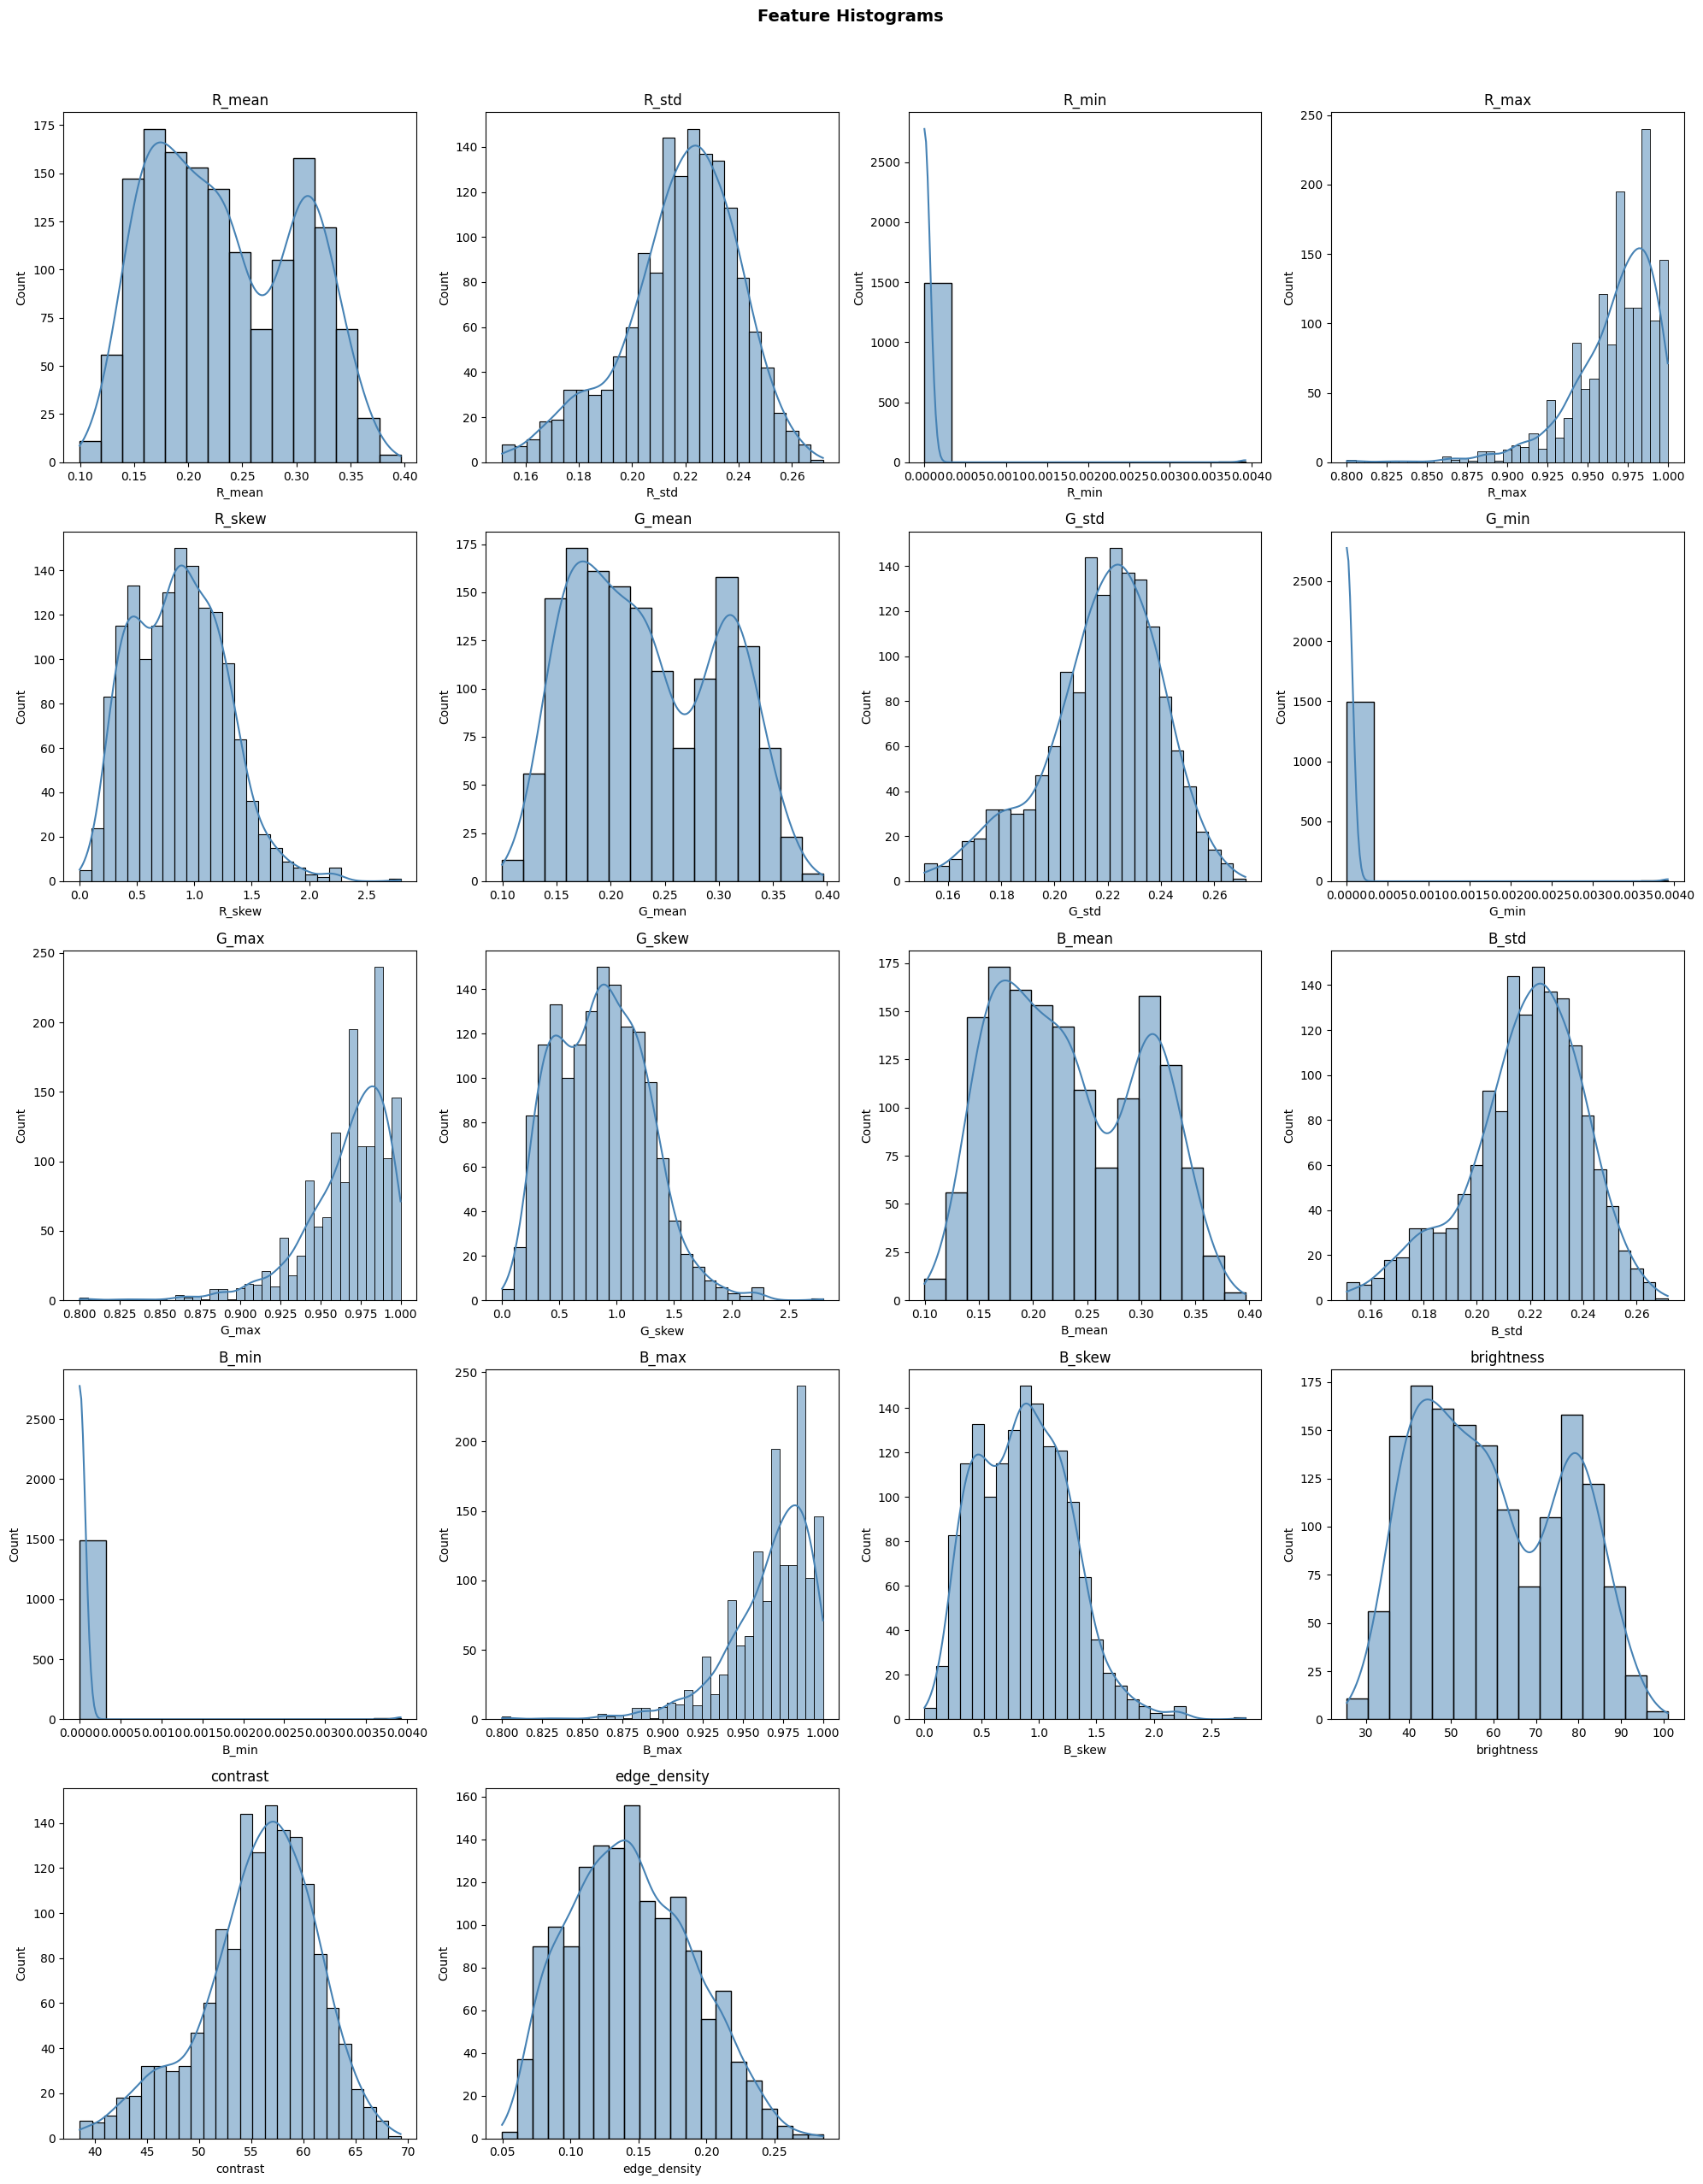

In [60]:
import math

n_features = len(feature_cols)
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(df_train[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Histograms', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


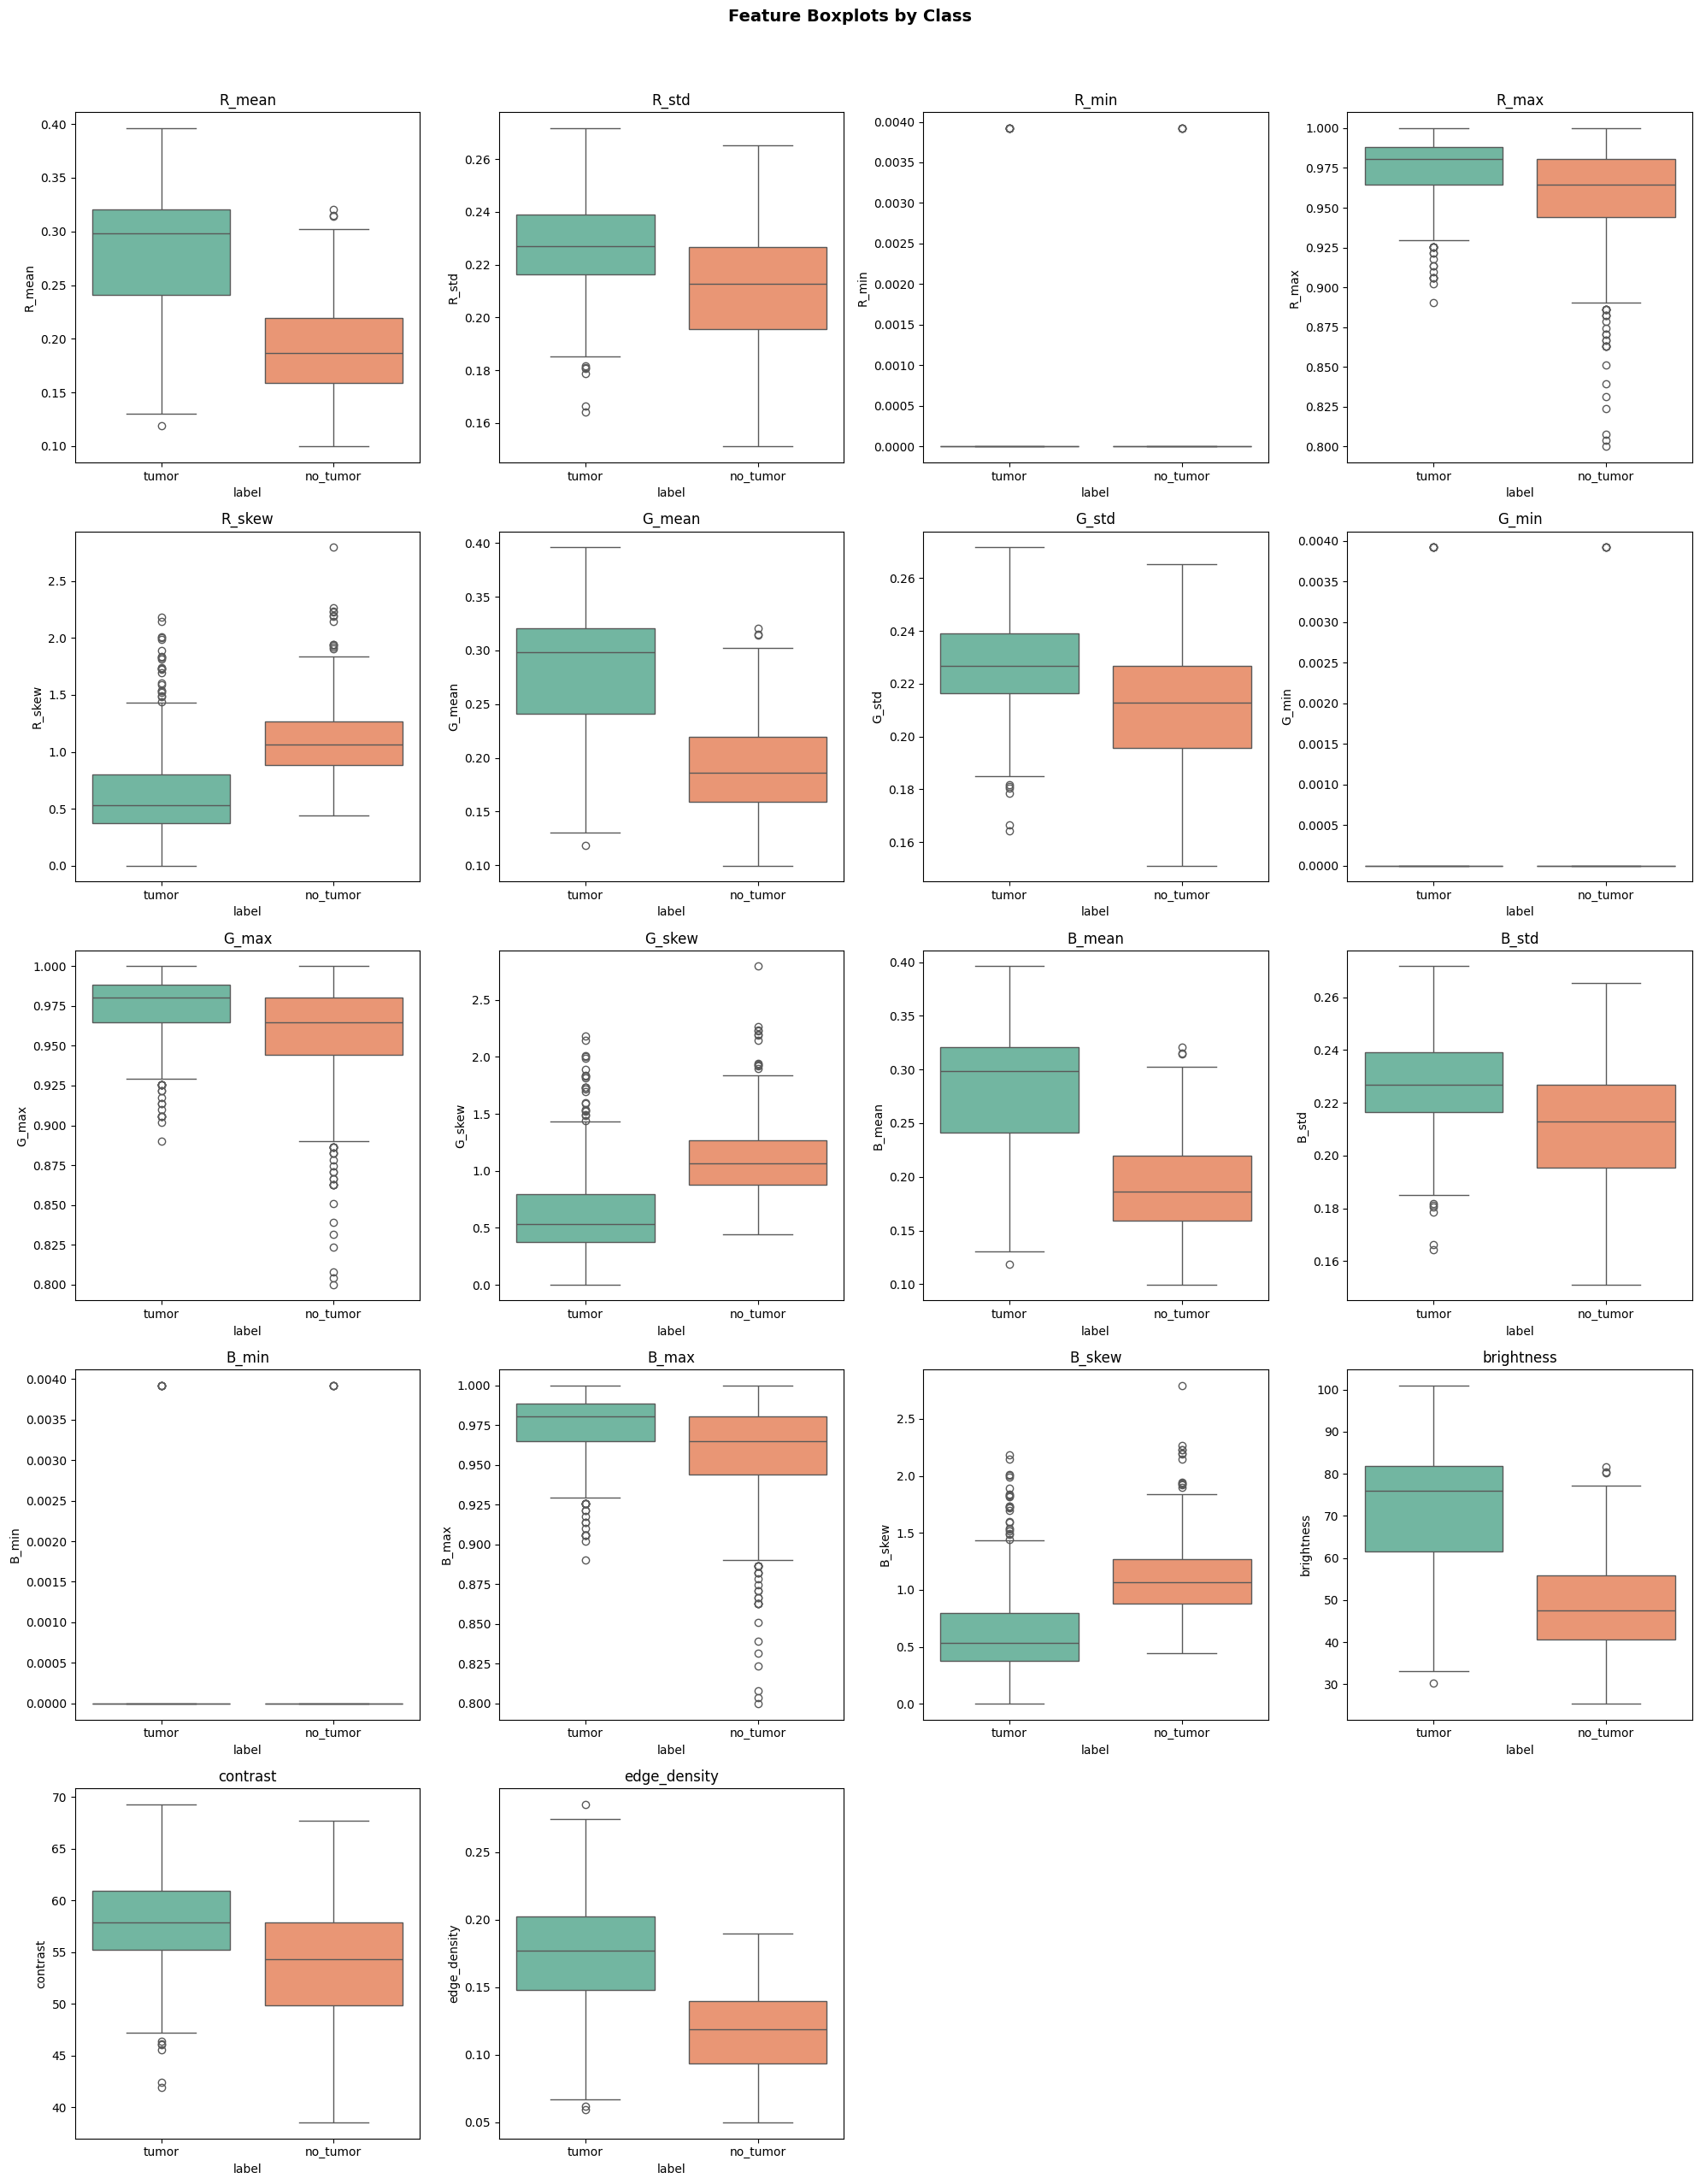

In [61]:
# --- Boxplots (by class) ---
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df_train, x='label', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(col)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Boxplots by Class', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


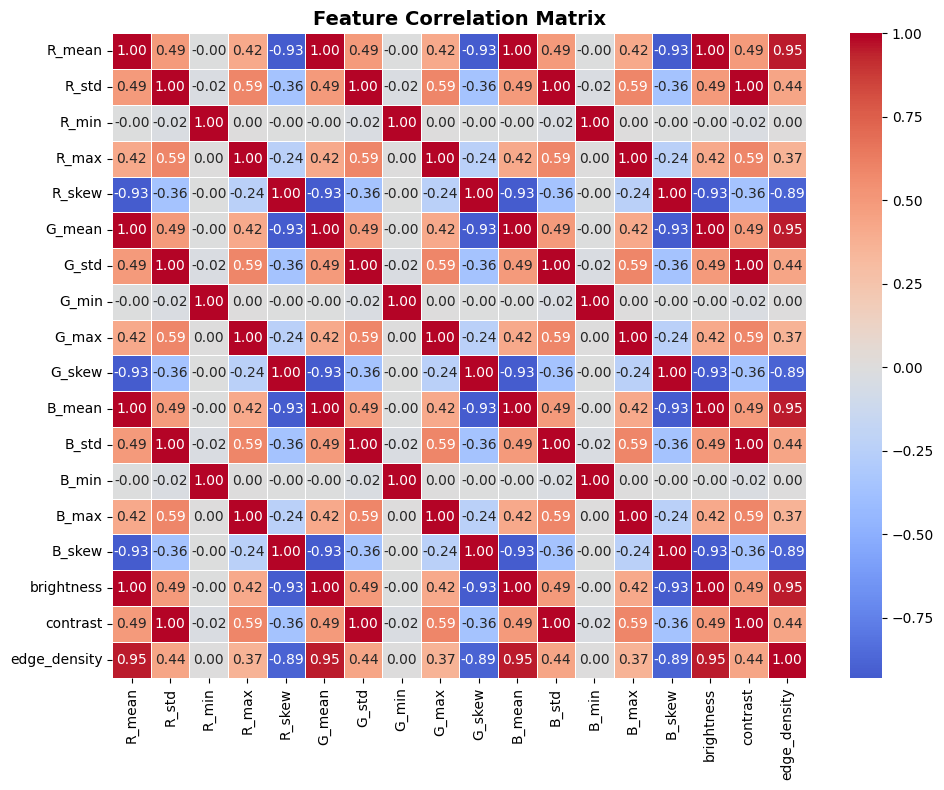

In [62]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
corr = df_train[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


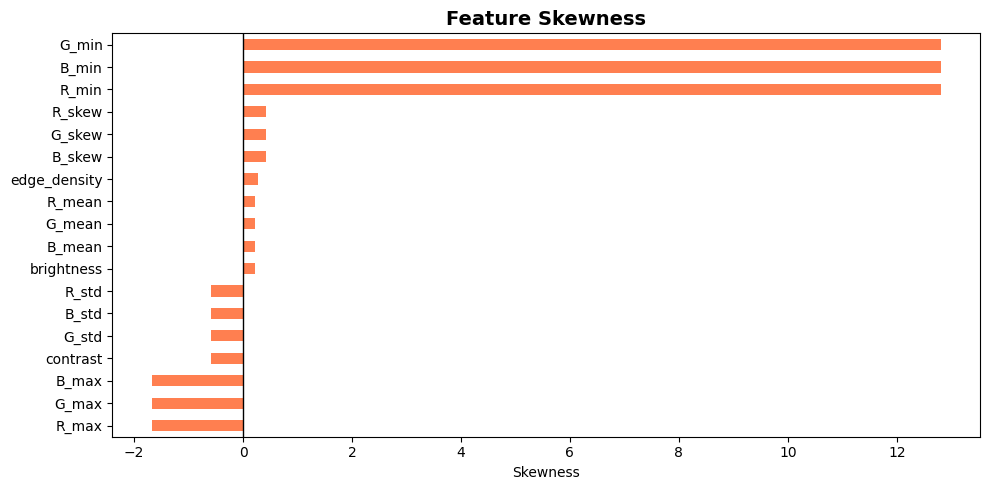

R_max           -1.674340
G_max           -1.674340
B_max           -1.674340
contrast        -0.588523
G_std           -0.588521
B_std           -0.588521
R_std           -0.588521
brightness       0.210999
B_mean           0.211000
G_mean           0.211000
R_mean           0.211000
edge_density     0.282858
B_skew           0.420101
G_skew           0.420101
R_skew           0.420101
R_min           12.802142
B_min           12.802142
G_min           12.802142
dtype: float64


In [63]:
# --- Skewness ---
skew_vals = df_train[feature_cols].apply(lambda c: skew(c.dropna())).sort_values()
plt.figure(figsize=(10, 5))
skew_vals.plot(kind='barh', color='coral')
plt.axvline(0, color='black', lw=1)
plt.title('Feature Skewness', fontsize=14, fontweight='bold')
plt.xlabel('Skewness')
plt.tight_layout()
plt.show()

print(skew_vals)


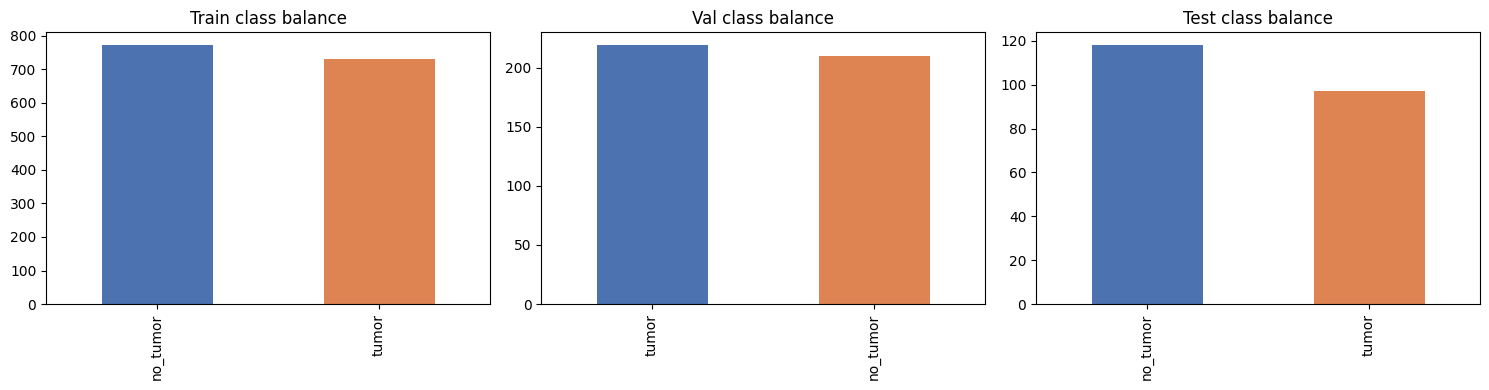

In [64]:
# --- Class balance (relevant later for both the CNN loss and FL client design) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df_) in zip(axes, [('Train', df_train), ('Val', df_val), ('Test', df_test)]):
    df_['label'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
    ax.set_title(f'{name} class balance')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()


## 6. Feature Selection

In [65]:
# Drop near-zero-variance features
vt = VarianceThreshold(threshold=1e-4)
vt.fit(df_train[feature_cols])
kept_by_variance = list(np.array(feature_cols)[vt.get_support()])
print(f"Kept after variance threshold: {kept_by_variance}")

# Drop one of each highly-correlated (|corr| > 0.95) feature pair
corr_matrix = df_train[kept_by_variance].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]
selected_features = [c for c in kept_by_variance if c not in to_drop]

print(f"Dropped (highly correlated): {to_drop}")
print(f"\n✅ Final selected features ({len(selected_features)}): {selected_features}")


Kept after variance threshold: [np.str_('R_mean'), np.str_('R_std'), np.str_('R_max'), np.str_('R_skew'), np.str_('G_mean'), np.str_('G_std'), np.str_('G_max'), np.str_('G_skew'), np.str_('B_mean'), np.str_('B_std'), np.str_('B_max'), np.str_('B_skew'), np.str_('brightness'), np.str_('contrast'), np.str_('edge_density')]
Dropped (highly correlated): ['G_mean', 'G_std', 'G_max', 'G_skew', 'B_mean', 'B_std', 'B_max', 'B_skew', 'brightness', 'contrast']

✅ Final selected features (5): [np.str_('R_mean'), np.str_('R_std'), np.str_('R_max'), np.str_('R_skew'), np.str_('edge_density')]


## 7. Train-Test Split

In [66]:
# --- Tabular split (for Random Forest) ---
X_feat = pd.concat([df_train, df_val], ignore_index=True)[selected_features]
y_feat = pd.concat([df_train, df_val], ignore_index=True)['label_enc']

X_feat_train, X_feat_holdout, y_feat_train, y_feat_holdout = train_test_split(
    X_feat, y_feat, test_size=0.2, stratify=y_feat, random_state=RANDOM_STATE
)

scaler = StandardScaler().fit(X_feat_train)
X_feat_train_s   = scaler.transform(X_feat_train)
X_feat_holdout_s = scaler.transform(X_feat_holdout)
X_feat_test_s    = scaler.transform(df_test[selected_features])
y_feat_test      = df_test['label_enc'].values

print(f"RF split -> Train: {X_feat_train_s.shape} | Holdout: {X_feat_holdout_s.shape} | Test: {X_feat_test_s.shape}")

# --- Raw-image split (for the Neural Network / Federated Learning) ---
# align raw images with the cleaned/label-filtered dataframes
X_train_img = X_train_raw[df_train.index.to_numpy()] if len(df_train) == len(X_train_raw) else X_train_raw[:len(df_train)]
y_train_img = df_train['label_enc'].values
X_val_img   = X_val_raw[df_val.index.to_numpy()] if len(df_val) == len(X_val_raw) else X_val_raw[:len(df_val)]
y_val_img   = df_val['label_enc'].values
X_test_img  = X_test_raw[df_test.index.to_numpy()] if len(df_test) == len(X_test_raw) else X_test_raw[:len(df_test)]
y_test_img  = df_test['label_enc'].values

print(f"NN split  -> Train: {X_train_img.shape} | Val: {X_val_img.shape} | Test: {X_test_img.shape}")


RF split -> Train: (1544, 5) | Holdout: (387, 5) | Test: (215, 5)
NN split  -> Train: (1502, 128, 128, 3) | Val: (429, 128, 128, 3) | Test: (215, 128, 128, 3)


## 8. Baseline: Random Forest (Classical ML Reference)

✅ Random Forest — Holdout Accuracy: 0.8475452196382429
✅ Random Forest — Test Accuracy   : 0.9162790697674419

              precision    recall  f1-score   support

    no_tumor       0.94      0.91      0.92       118
       tumor       0.89      0.93      0.91        97

    accuracy                           0.92       215
   macro avg       0.91      0.92      0.92       215
weighted avg       0.92      0.92      0.92       215



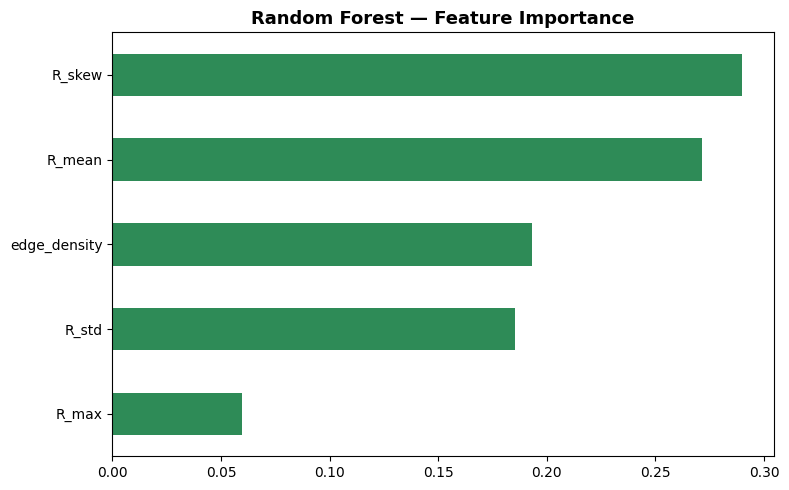

In [67]:
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=12, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_feat_train_s, y_feat_train)

rf_holdout_pred = rf_model.predict(X_feat_holdout_s)
rf_test_pred    = rf_model.predict(X_feat_test_s)
rf_test_proba   = rf_model.predict_proba(X_feat_test_s)[:, 1]

print("✅ Random Forest — Holdout Accuracy:", accuracy_score(y_feat_holdout, rf_holdout_pred))
print("✅ Random Forest — Test Accuracy   :", accuracy_score(y_feat_test, rf_test_pred))
print()
print(classification_report(y_feat_test, rf_test_pred, target_names=label_encoder.classes_))

# Feature importance
importances = pd.Series(rf_model.feature_importances_, index=selected_features).sort_values()
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='seagreen')
plt.title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Centralized CNN Baseline

This is the deep-learning model that both (a) serves as the accuracy ceiling
for the "all data in one place" scenario, and (b) provides the architecture
and warm-start weights used by every federated client later on — the
centralized and federated models must share the same architecture for the
comparison in the final section to be meaningful.

In [68]:
def build_cnn_classifier(img_size=IMG_SIZE, lr=LEARNING_RATE, name='CNN_Classifier'):
    inputs = layers.Input(shape=(img_size, img_size, 3))

    # Light on-the-fly augmentation — active only during training, a no-op at
    # inference time — helps the (fairly small) centralized model generalize
    # and keeps the augmentation identical across every FL client.
    x = layers.RandomFlip('horizontal')(inputs)
    x = layers.RandomRotation(0.05)(x)
    x = layers.RandomZoom(0.05)(x)

    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name=name)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


# Class weights, computed from the training split, correct for any tumor /
# no_tumor imbalance visible in the class-balance plot in the EDA section.
classes, counts = np.unique(y_train_img, return_counts=True)
class_weight = {int(c): len(y_train_img) / (len(classes) * n) for c, n in zip(classes, counts)}
print("Class weights:", class_weight)

nn_model = build_cnn_classifier(name='Centralized_CNN')
nn_model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
]

nn_history = nn_model.fit(
    X_train_img, y_train_img,
    validation_data=(X_val_img, y_val_img),
    epochs=NN_EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight, callbacks=callbacks, verbose=1
)

nn_test_loss, nn_test_acc = nn_model.evaluate(X_test_img, y_test_img, verbose=0)
print(f"\n✅ Neural Network — Test Accuracy: {nn_test_acc:.4f}")


Class weights: {0: np.float64(0.9727979274611399), 1: np.float64(1.0287671232876712)}


Model: "Centralized_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_34 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_34 (RandomFlip)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_34              │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_34 (RandomZoom)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_102 (Conv2D)             │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_102         │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_102               │ (None, 64, 64, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_103 (Conv2D)             │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_103         │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_103               │ (None, 32, 32, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_104 (Conv2D)             │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_104         │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_104               │ (None, 16, 16, 128)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_34     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,465 (400.25 KB)

 Trainable params: 102,017 (398.50 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.7756 - loss: 0.4584 - val_accuracy: 0.4895 - val_loss: 0.6830 - learning_rate: 1.0000e-04
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8216 - loss: 0.3951 - val_accuracy: 0.4895 - val_loss: 0.9274 - learning_rate: 1.0000e-04
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8309 - loss: 0.3756 - val_accuracy: 0.4895 - val_loss: 1.2358 - learning_rate: 1.0000e-04
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8529 - loss: 0.3517 - val_accuracy: 0.5012 - val_loss: 0.9319 - learning_rate: 5.0000e-05
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8555 - loss: 0.3337 - val_accuracy: 0.6923 - val_loss: 0.5806 - learning_rate: 5.0000e-05
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8595 - loss: 0.3206 - val_accuracy: 0.8345 - val_loss: 0.3692 - learning_rate: 5.0000e-05
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8755 

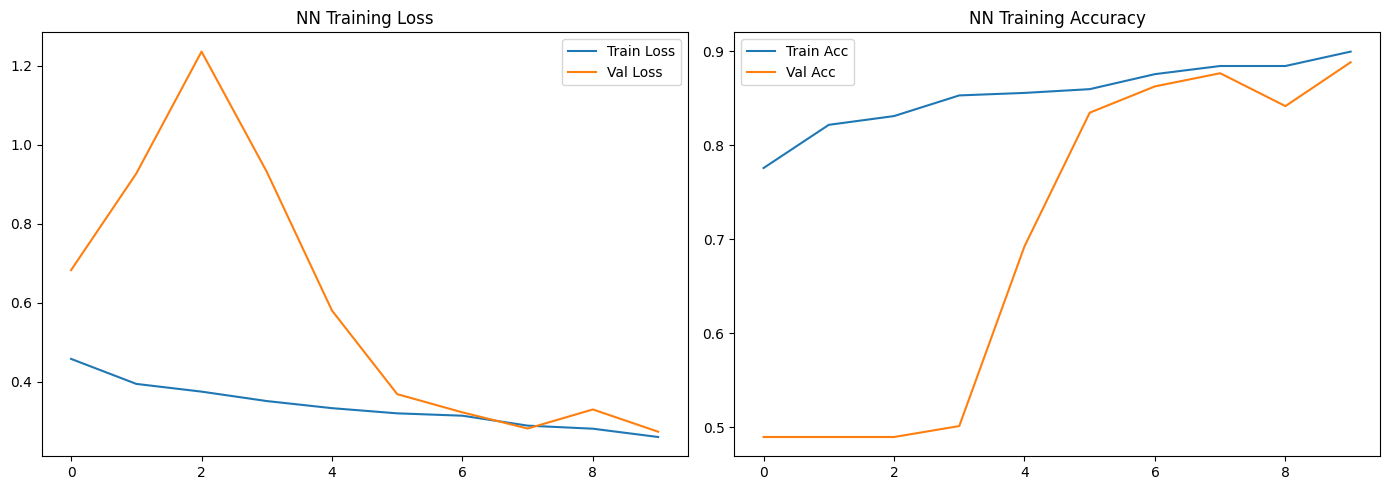

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(nn_history.history['loss'], label='Train Loss')
axes[0].plot(nn_history.history['val_loss'], label='Val Loss')
axes[0].set_title('NN Training Loss'); axes[0].legend()

axes[1].plot(nn_history.history['accuracy'], label='Train Acc')
axes[1].plot(nn_history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('NN Training Accuracy'); axes[1].legend()
plt.tight_layout()
plt.show()


## 10. Centralized Model Evaluation

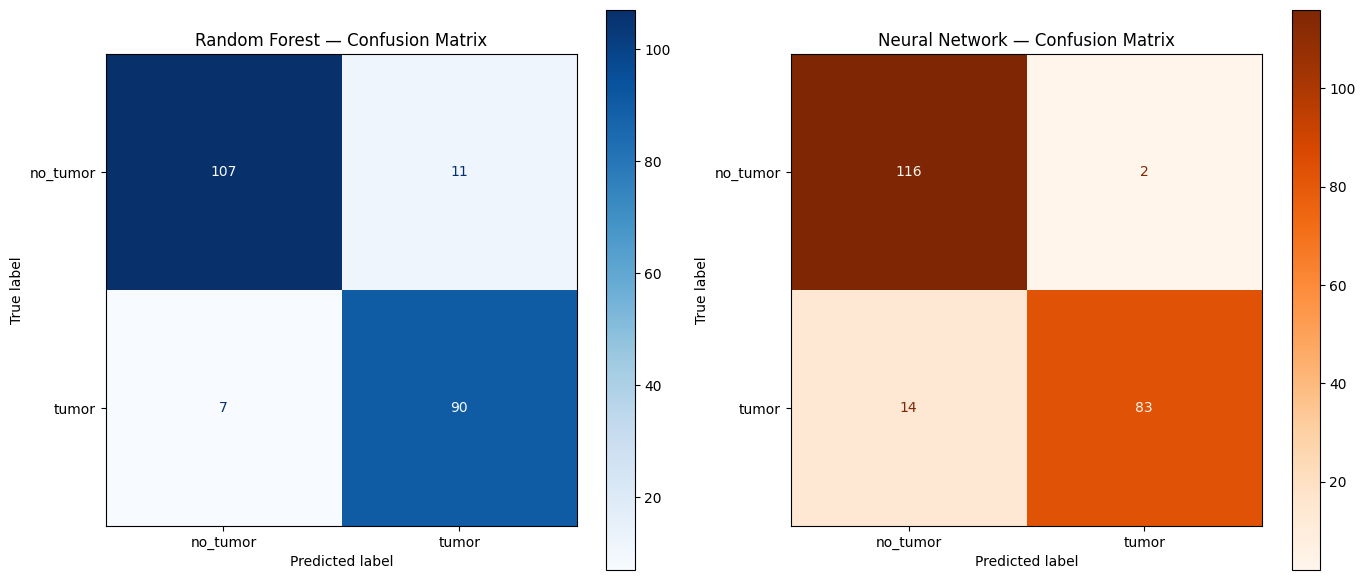

In [70]:
nn_test_proba = nn_model.predict(X_test_img, verbose=0).flatten()
nn_test_pred  = (nn_test_proba > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_rf = confusion_matrix(y_feat_test, rf_test_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=label_encoder.classes_).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Random Forest — Confusion Matrix')

cm_nn = confusion_matrix(y_test_img, nn_test_pred)
ConfusionMatrixDisplay(cm_nn, display_labels=label_encoder.classes_).plot(ax=axes[1], cmap='Oranges')
axes[1].set_title('Neural Network — Confusion Matrix')

plt.tight_layout()
plt.show()


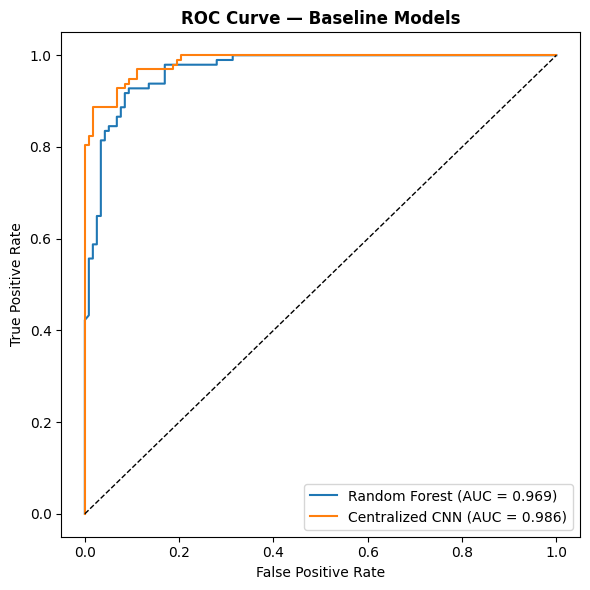

Random Forest    — Precision: 0.8911 | Recall: 0.9278 | F1: 0.9091 | AUC: 0.9688
Centralized CNN  — Precision: 0.9765 | Recall: 0.8557 | F1: 0.9121 | AUC: 0.9858


In [71]:
# --- ROC curves: Random Forest vs. Centralized CNN ---
fpr_rf, tpr_rf, _ = roc_curve(y_feat_test, rf_test_proba)
fpr_nn, tpr_nn, _ = roc_curve(y_test_img, nn_test_proba)
auc_rf = roc_auc_score(y_feat_test, rf_test_proba)
auc_nn = roc_auc_score(y_test_img, nn_test_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_nn, tpr_nn, label=f'Centralized CNN (AUC = {auc_nn:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Baseline Models', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Random Forest    — Precision: {precision_score(y_feat_test, rf_test_pred):.4f} | "
      f"Recall: {recall_score(y_feat_test, rf_test_pred):.4f} | "
      f"F1: {f1_score(y_feat_test, rf_test_pred):.4f} | AUC: {auc_rf:.4f}")
print(f"Centralized CNN  — Precision: {precision_score(y_test_img, nn_test_pred):.4f} | "
      f"Recall: {recall_score(y_test_img, nn_test_pred):.4f} | "
      f"F1: {f1_score(y_test_img, nn_test_pred):.4f} | AUC: {auc_nn:.4f}")


## 11. Save Model Weights

In [72]:
nn_model.save_weights(os.path.join(MODEL_DIR, 'centralized_cnn.weights.h5'))
joblib.dump(rf_model, os.path.join(MODEL_DIR, 'random_forest.joblib'))
joblib.dump(scaler,   os.path.join(MODEL_DIR, 'feature_scaler.joblib'))
joblib.dump(label_encoder, os.path.join(MODEL_DIR, 'label_encoder.joblib'))

print("✅ Saved: centralized_cnn.weights.h5, random_forest.joblib, feature_scaler.joblib, label_encoder.joblib")


✅ Saved: centralized_cnn.weights.h5, random_forest.joblib, feature_scaler.joblib, label_encoder.joblib


## 12. Federated Learning — Create Clients

Two partitioning strategies are provided:

- **IID** — the training set is shuffled and split into equal shards. Every
  client sees roughly the same label distribution as the global dataset.
  This is the "easy case" for FL and is what most introductory FL demos use.
- **Non-IID (label-skew via a Dirichlet distribution)** — a more realistic
  simulation of independent hospitals, where each site may see disproportionately
  more of one class (e.g. a specialist tumor clinic vs. a general screening
  center). Smaller `DIRICHLET_ALPHA` -> more skewed clients. This is included
  because a thesis claiming an FL system "works" should also report how it
  degrades under realistic heterogeneity, not just the IID best case.

`CLIENT_PARTITION` in the Config cell controls which one is used for the
training run below; the client-distribution plot shows exactly what each
client received either way.

Partitioning strategy: iid
  Client 1: 300 samples | tumor=150 | no_tumor=150
  Client 2: 300 samples | tumor=145 | no_tumor=155
  Client 3: 300 samples | tumor=142 | no_tumor=158
  Client 4: 300 samples | tumor=149 | no_tumor=151
  Client 5: 302 samples | tumor=144 | no_tumor=158


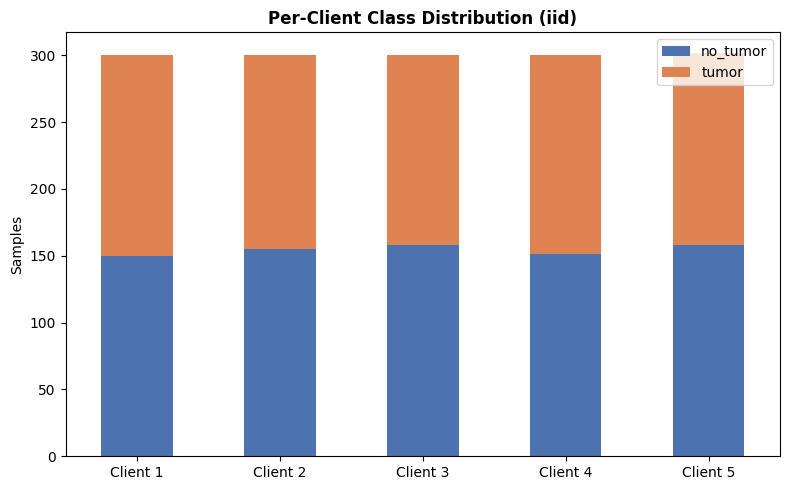

In [73]:
def create_iid_clients(X, y, num_clients=NUM_CLIENTS, seed=RANDOM_STATE):
    """Randomly partition the training data into `num_clients` equally
    sized, IID shards — simulates independent hospitals with private data."""
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(X))
    X, y = X[idx], y[idx]
    size = len(X) // num_clients
    clients = []
    for i in range(num_clients):
        start = i * size
        end   = start + size if i < num_clients - 1 else len(X)
        clients.append((X[start:end], y[start:end]))
    return clients


def create_noniid_clients(X, y, num_clients=NUM_CLIENTS, alpha=DIRICHLET_ALPHA, seed=RANDOM_STATE):
    """Label-skewed, non-IID partition using a Dirichlet distribution over
    class proportions per client (the standard approach in the FL literature,
    e.g. Hsu et al. 2019, for simulating heterogeneous clients)."""
    rng = np.random.RandomState(seed)
    classes = np.unique(y)
    client_indices = [[] for _ in range(num_clients)]

    for c in classes:
        c_idx = np.where(y == c)[0]
        rng.shuffle(c_idx)
        proportions = rng.dirichlet(alpha=[alpha] * num_clients)
        split_points = (np.cumsum(proportions) * len(c_idx)).astype(int)[:-1]
        for client_id, idx_chunk in enumerate(np.split(c_idx, split_points)):
            client_indices[client_id].extend(idx_chunk.tolist())

    clients = []
    for idx_list in client_indices:
        idx_arr = np.array(idx_list)
        rng.shuffle(idx_arr)
        clients.append((X[idx_arr], y[idx_arr]))
    return clients


if CLIENT_PARTITION == 'non_iid':
    fl_clients = create_noniid_clients(X_train_img, y_train_img, NUM_CLIENTS, DIRICHLET_ALPHA)
else:
    fl_clients = create_iid_clients(X_train_img, y_train_img, NUM_CLIENTS)

print(f"Partitioning strategy: {CLIENT_PARTITION}")
for i, (cx, cy) in enumerate(fl_clients):
    print(f"  Client {i+1}: {cx.shape[0]} samples | "
          f"tumor={int(cy.sum())} | no_tumor={int((cy==0).sum())}")

# Visualize the per-client class distribution
client_dist = pd.DataFrame({
    f'Client {i+1}': [int((cy == c).sum()) for c in classes]
    for i, (cx, cy) in enumerate(fl_clients)
}, index=[label_encoder.classes_[c] for c in classes]).T

client_dist.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#4C72B0', '#DD8452'])
plt.title(f'Per-Client Class Distribution ({CLIENT_PARTITION})', fontweight='bold')
plt.ylabel('Samples'); plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 13. Local CNN Training — Gradient Computation

Each client trains a fresh **copy** of the global CNN on its own private
data and reports back a gradient summary rather than raw images — this is
the privacy-preserving property that motivates federated learning in a
medical-imaging setting.

In [74]:
def compute_local_gradients(global_weights, client_X, client_y, epochs=EPOCHS_PER_CLIENT):
    """
    Train a fresh copy of the CNN on this client's local data and capture the
    *gradient* values produced during local training (rather than only the
    final local weights). Returns:
      - avg_grads   : mean gradient per trainable layer, accumulated over all
                       local batches/epochs on this client
      - bn_state    : client's final non-trainable weights (BatchNorm running
                       mean/var), which have no gradient of their own and are
                       still combined the classic FedAvg (weighted-average) way
      - n_samples   : number of samples the client trained on, used to weight
                       this client's contribution during server-side aggregation
    """
    local_model = build_cnn_classifier(name='client_tmp')
    local_model.set_weights(global_weights)

    local_optimizer = tf.keras.optimizers.Adam(LEARNING_RATE)
    loss_fn = tf.keras.losses.BinaryCrossentropy()

    trainable_vars = local_model.trainable_variables
    grad_sum  = [tf.zeros_like(v) for v in trainable_vars]
    n_batches = 0

    ds = tf.data.Dataset.from_tensor_slices((client_X, client_y)) \
                         .shuffle(len(client_X), seed=RANDOM_STATE) \
                         .batch(BATCH_SIZE)

    for epoch in range(epochs):
        for xb, yb in ds:
            yb = tf.cast(tf.reshape(yb, (-1, 1)), tf.float32)
            with tf.GradientTape() as tape:
                preds = local_model(xb, training=True)
                loss  = loss_fn(yb, preds)
            grads = tape.gradient(loss, trainable_vars)

            # accumulate the raw gradient values produced by this client
            grad_sum  = [gs + g for gs, g in zip(grad_sum, grads)]
            n_batches += 1

            # local optimizer step so later batches/epochs still reflect the
            # model actually learning on this client's data
            local_optimizer.apply_gradients(zip(grads, trainable_vars))

    avg_grads = [gs / max(n_batches, 1) for gs in grad_sum]

    non_trainable_vars = local_model.non_trainable_weights
    bn_state = [v.numpy() for v in non_trainable_vars]

    return avg_grads, bn_state, len(client_X)


## 14. Gradient Aggregation & Global Model Update

The server never receives raw client data — only each client's averaged
gradient and BatchNorm running statistics — and combines them with a
sample-size-weighted average (the same weighting principle as classic
FedAvg, applied here to gradients rather than final weights) before taking
a single global optimizer step.

In [75]:
def aggregate_gradients(client_grads_list, client_sizes):
    """Size-weighted average of client gradients (same weighting idea as
    FedAvg, applied to gradients instead of weights)."""
    total = sum(client_sizes)
    agg = []
    for layer_grads in zip(*client_grads_list):
        weighted = tf.add_n([g * (s / total) for g, s in zip(layer_grads, client_sizes)])
        agg.append(weighted)
    return agg


def aggregate_bn_state(client_bn_list, client_sizes):
    """Size-weighted average of BatchNorm running stats (no gradient exists
    for these, so they are still combined the classic FedAvg way)."""
    total = sum(client_sizes)
    agg = []
    for layer_vals in zip(*client_bn_list):
        weighted = np.sum([v * s / total for v, s in zip(layer_vals, client_sizes)], axis=0)
        agg.append(weighted)
    return agg


print("=" * 70)
print(" FEDERATED LEARNING — CNN Classifier (Gradient Aggregation)")
print("=" * 70)
print(f"  Clients      : {NUM_CLIENTS} hospitals ({CLIENT_PARTITION})")
print(f"  FL Rounds    : {NUM_ROUNDS}")
print(f"  Local Epochs : {EPOCHS_PER_CLIENT} per client per round")
print(f"  Aggregation  : server-side Adam step applied to the size-weighted")
print(f"                 average of each client's local gradients")
print()

fl_global_model = build_cnn_classifier(name='FL_Global_CNN')
fl_global_model.load_weights(os.path.join(MODEL_DIR, 'centralized_cnn.weights.h5'))  # warm start (optional)

server_optimizer = tf.keras.optimizers.Adam(LEARNING_RATE)
trainable_vars   = fl_global_model.trainable_variables

# Number of scalar parameters transmitted client -> server per round, used
# for the communication-cost comparison in the final section.
n_params_per_client_msg = sum(int(np.prod(v.shape)) for v in trainable_vars)

fl_val_acc_per_round = []
round_times = []

for rnd in range(NUM_ROUNDS):
    t0 = time.time()
    print(f"\n{'─'*60}")
    print(f" FL Round {rnd+1}/{NUM_ROUNDS}")
    print(f"{'─'*60}")

    global_weights = fl_global_model.get_weights()

    client_grads_list, client_bn_list, client_sizes = [], [], []
    for i, (cx, cy) in enumerate(fl_clients):
        grads, bn_state, n = compute_local_gradients(global_weights, cx, cy)
        client_grads_list.append(grads)
        client_bn_list.append(bn_state)
        client_sizes.append(n)
        print(f"   Client {i+1}/{NUM_CLIENTS} — local gradients computed ({n} samples)")

    # ---- server-side step: this is where the global model is actually
    # trained using the (aggregated) gradient values from the clients ----
    agg_grads = aggregate_gradients(client_grads_list, client_sizes)
    server_optimizer.apply_gradients(zip(agg_grads, trainable_vars))

    # BatchNorm running stats have no gradient -> combine FedAvg-style
    agg_bn = aggregate_bn_state(client_bn_list, client_sizes)
    for v, new_val in zip(fl_global_model.non_trainable_weights, agg_bn):
        v.assign(new_val)

    val_loss, val_acc = fl_global_model.evaluate(X_val_img, y_val_img, verbose=0)
    fl_val_acc_per_round.append(val_acc)
    round_times.append(time.time() - t0)
    print(f"   ✅ Round {rnd+1} — Global Model Val Accuracy: {val_acc:.4f} "
          f"(round wall-time: {round_times[-1]:.1f}s)")

print("\n✅ Gradient-based Federated Learning complete.")


 FEDERATED LEARNING — CNN Classifier (Gradient Aggregation)
  Clients      : 5 hospitals (iid)
  FL Rounds    : 3
  Local Epochs : 2 per client per round
  Aggregation  : server-side Adam step applied to the size-weighted
                 average of each client's local gradients


────────────────────────────────────────────────────────────
 FL Round 1/3
────────────────────────────────────────────────────────────
   Client 1/5 — local gradients computed (300 samples)
   Client 2/5 — local gradients computed (300 samples)
   Client 3/5 — local gradients computed (300 samples)
   Client 4/5 — local gradients computed (300 samples)
   Client 5/5 — local gradients computed (302 samples)
   ✅ Round 1 — Global Model Val Accuracy: 0.8881 (round wall-time: 30.1s)

────────────────────────────────────────────────────────────
 FL Round 2/3
────────────────────────────────────────────────────────────
   Client 1/5 — local gradients computed (300 samples)
   Client 2/5 — local gradients computed 

## 15. Global Model Evaluation

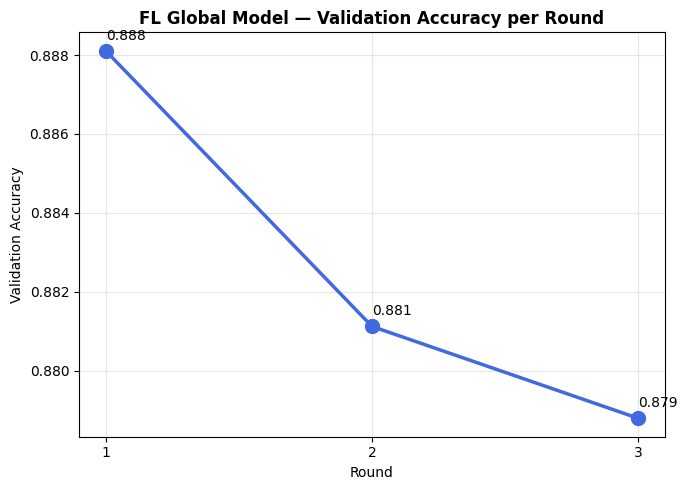

✅ FL Global Model — Test Accuracy: 0.9116 | Test Loss: 0.2309
✅ Saved: federated_global_cnn.weights.h5


In [76]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, NUM_ROUNDS + 1), fl_val_acc_per_round, 'o-', color='royalblue', lw=2.5, ms=10)
for x, y_ in zip(range(1, NUM_ROUNDS + 1), fl_val_acc_per_round):
    plt.annotate(f'{y_:.3f}', (x, y_), textcoords="offset points", xytext=(0, 8))
plt.title('FL Global Model — Validation Accuracy per Round', fontweight='bold')
plt.xlabel('Round'); plt.ylabel('Validation Accuracy')
plt.xticks(range(1, NUM_ROUNDS + 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fl_test_loss, fl_test_acc = fl_global_model.evaluate(X_test_img, y_test_img, verbose=0)
print(f"✅ FL Global Model — Test Accuracy: {fl_test_acc:.4f} | Test Loss: {fl_test_loss:.4f}")

fl_global_model.save_weights(os.path.join(MODEL_DIR, 'federated_global_cnn.weights.h5'))
print("✅ Saved: federated_global_cnn.weights.h5")


## 16. Comparison with Centralized CNN

Final head-to-head across all three models: the classical Random Forest
baseline, the centralized CNN (upper bound — trains on all data with no
communication constraint), and the Federated Global Model (trains only on
gradients aggregated from distributed, private clients). For a thesis, the
key result is *how close* the federated model gets to the centralized
upper bound, at what communication cost, and — if `CLIENT_PARTITION =
'non_iid'` was used above — how much that gap widens under realistic
client heterogeneity.

                       Model  Accuracy  Precision   Recall       F1  ROC-AUC
               Random Forest  0.916279   0.891089 0.927835 0.909091 0.968766
Neural Network (Centralized)  0.925581   0.976471 0.855670 0.912088 0.985847
      Federated Global Model  0.911628   0.987500 0.814433 0.892655 0.990826


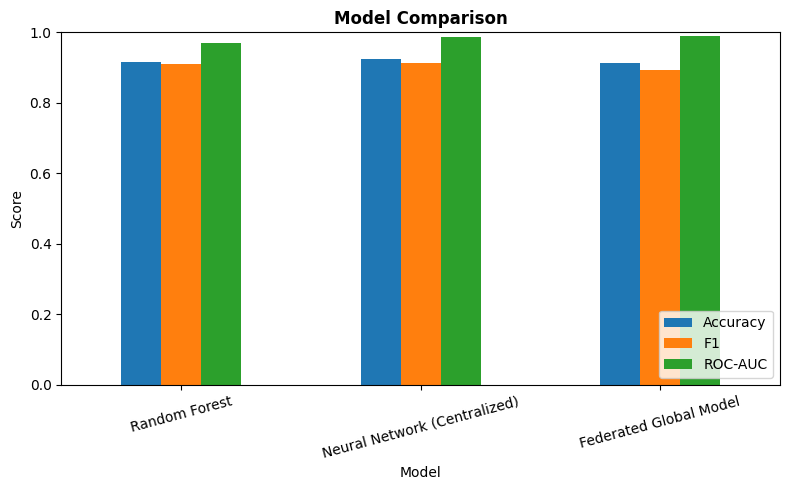

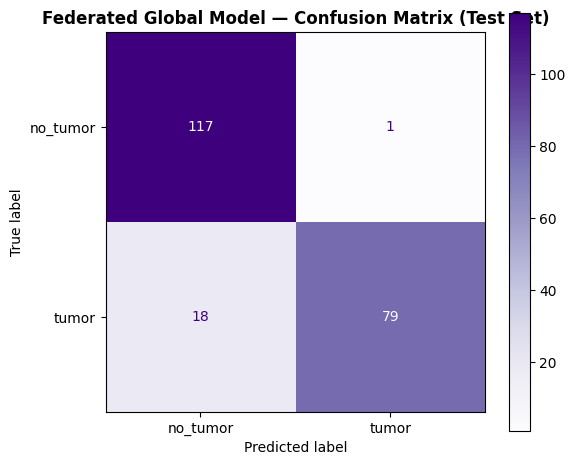


              precision    recall  f1-score   support

    no_tumor       0.87      0.99      0.92       118
       tumor       0.99      0.81      0.89        97

    accuracy                           0.91       215
   macro avg       0.93      0.90      0.91       215
weighted avg       0.92      0.91      0.91       215



In [77]:
fl_test_proba = fl_global_model.predict(X_test_img, verbose=0).flatten()
fl_test_pred  = (fl_test_proba > 0.5).astype(int)

results = pd.DataFrame({
    'Model': ['Random Forest', 'Neural Network (Centralized)', 'Federated Global Model'],
    'Accuracy':  [accuracy_score(y_feat_test, rf_test_pred), nn_test_acc, fl_test_acc],
    'Precision': [precision_score(y_feat_test, rf_test_pred),
                  precision_score(y_test_img, nn_test_pred),
                  precision_score(y_test_img, fl_test_pred)],
    'Recall':    [recall_score(y_feat_test, rf_test_pred),
                  recall_score(y_test_img, nn_test_pred),
                  recall_score(y_test_img, fl_test_pred)],
    'F1':        [f1_score(y_feat_test, rf_test_pred),
                  f1_score(y_test_img, nn_test_pred),
                  f1_score(y_test_img, fl_test_pred)],
    'ROC-AUC':   [auc_rf, auc_nn, roc_auc_score(y_test_img, fl_test_proba)],
})
print(results.to_string(index=False))

results.to_csv(os.path.join(MODEL_DIR, 'model_comparison_results.csv'), index=False)

fig, ax = plt.subplots(figsize=(8, 5))
results.set_index('Model')[['Accuracy', 'F1', 'ROC-AUC']].plot(kind='bar', ax=ax)
plt.title('Model Comparison', fontweight='bold')
plt.ylabel('Score'); plt.ylim(0, 1); plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
cm_fl = confusion_matrix(y_test_img, fl_test_pred)
ConfusionMatrixDisplay(cm_fl, display_labels=label_encoder.classes_).plot(ax=ax, cmap='Purples')
ax.set_title('Federated Global Model — Confusion Matrix (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + classification_report(y_test_img, fl_test_pred, target_names=label_encoder.classes_))


In [78]:
# --- Communication cost of federated training vs. sending all raw data ---
bytes_per_param = 4  # float32
comm_bytes_total = n_params_per_client_msg * NUM_CLIENTS * NUM_ROUNDS * bytes_per_param * 2  # up + down
raw_image_bytes  = X_train_img.nbytes  # what centralizing the raw dataset would cost to transmit once

print(f"Model parameters transmitted per client per round : {n_params_per_client_msg:,}")
print(f"Total FL communication volume ({NUM_ROUNDS} rounds, "
      f"{NUM_CLIENTS} clients, up+down)     : {comm_bytes_total/1e6:.1f} MB")
print(f"Equivalent one-shot cost of centralizing raw images        : {raw_image_bytes/1e6:.1f} MB")
print(f"Average FL round wall-time                                 : {np.mean(round_times):.1f}s")
print()
print("Interpretation: federated learning trades some accuracy / extra rounds "
      "for never transmitting raw patient images off-site — the relevant "
      "privacy-utility trade-off to report and discuss in the thesis.")


Model parameters transmitted per client per round : 102,017
Total FL communication volume (3 rounds, 5 clients, up+down)     : 12.2 MB
Equivalent one-shot cost of centralizing raw images        : 295.3 MB
Average FL round wall-time                                 : 29.8s

Interpretation: federated learning trades some accuracy / extra rounds for never transmitting raw patient images off-site — the relevant privacy-utility trade-off to report and discuss in the thesis.


## Notes for the Thesis Write-up

- **Baselines.** Random Forest (handcrafted features) and a centralized CNN
  (same architecture used by every FL client) give two reference points for
  "how good could this get without any FL constraint."
- **Federated protocol.** Gradient-based FedAvg: each client trains locally
  and reports averaged gradients + BatchNorm statistics; the server performs
  one Adam step on the size-weighted average and re-broadcasts the updated
  global model — repeated for `NUM_ROUNDS` communication rounds.
- **IID vs. non-IID.** Re-run the "Create Clients" section with
  `CLIENT_PARTITION = 'non_iid'` to reproduce the harder, more realistic
  setting and quantify the accuracy gap this introduces — a standard ablation
  expected in FL literature.
- **Limitations to disclose.** (1) Clients are simulated on one machine, so
  wall-clock numbers do not reflect real network latency between hospitals;
  (2) no differential privacy / secure aggregation is applied to the
  gradients themselves, only raw images are kept local; (3) `NUM_ROUNDS=3`
  and `EPOCHS_PER_CLIENT=2` are intentionally small for fast iteration —
  increase both for the final reported numbers.


# Part 2 — Semantic Segmentation: Centralized vs. Federated U-Net

Part 1 above (steps 1–16) treated this as a **binary classification** problem
(tumor / no_tumor) using handcrafted features + Random Forest, and a
centralized/federated CNN classifier.

Part 2 follows the rest of the thesis pipeline diagram and tackles the
**pixel-level segmentation** task instead — predicting a tumor mask, not just
a label — comparing:

- **Centralized CNN U-Net** vs. **Centralized Transformer U-Net**
- **Federated CNN U-Net** vs. **Federated Transformer U-Net** (FedAvg,
  IID + Non-IID clients, reusing the same client-partitioning code as Part 1)

evaluated with Dice, IoU, Precision, Recall and F1, plus client-wise,
convergence and communication-cost analysis.

## 17. Tumor Mask Generation

In [79]:
def _load_coco_segmentation(split_dir):
    '''Read this split's `_annotations.coco.json` (Roboflow export) and
    return {filename: [polygon, polygon, ...]} where each polygon is a flat
    [x1, y1, x2, y2, ...] list in ORIGINAL image pixel coordinates. Returns
    None if this split has no COCO json.'''
    coco_path = os.path.join(split_dir, '_annotations.coco.json')
    if not os.path.exists(coco_path):
        return None

    with open(coco_path) as f:
        coco = json.load(f)

    tumor_cat_ids = {
        c['id'] for c in coco.get('categories', [])
        if c.get('name', '').strip().lower() not in ('background', 'none', '0', '')
    }
    if not tumor_cat_ids:
        tumor_cat_ids = {c['id'] for c in coco.get('categories', [])}

    image_id_to_fname = {img['id']: img['file_name'] for img in coco['images']}
    image_id_to_size   = {img['id']: (img['width'], img['height']) for img in coco['images']}

    polys_by_fname = {}
    for ann in coco.get('annotations', []):
        if ann.get('category_id') not in tumor_cat_ids:
            continue
        fname = image_id_to_fname.get(ann['image_id'])
        if fname is None:
            continue
        seg = ann.get('segmentation', [])
        if not seg:
            continue
        polys_by_fname.setdefault(fname, {'polys': [], 'size': image_id_to_size[ann['image_id']]})
        for poly in seg:
            if isinstance(poly, list) and len(poly) >= 6:  # need >= 3 points
                polys_by_fname[fname]['polys'].append(poly)

    return polys_by_fname


def build_mask(fname, polys_entry, img_size=IMG_SIZE):
    '''Rasterize this image's tumor polygons into a binary {0,1} mask,
    resized to (img_size, img_size) to match the loaded/resized images.'''
    mask = np.zeros((img_size, img_size), dtype=np.uint8)
    if polys_entry is None:
        return mask

    orig_w, orig_h = polys_entry['size']
    canvas = np.zeros((orig_h, orig_w), dtype=np.uint8)
    for poly in polys_entry['polys']:
        pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
        pts = pts.round().astype(np.int32)
        cv2.fillPoly(canvas, [pts], color=1)

    mask = cv2.resize(canvas, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
    return mask


def build_masks_for_split(split_dir, fnames):
    '''Build a (N, IMG_SIZE, IMG_SIZE, 1) float32 mask array aligned to the
    already-loaded/cleaned `fnames` list for this split.'''
    polys_by_fname = _load_coco_segmentation(split_dir) or {}
    masks = np.zeros((len(fnames), IMG_SIZE, IMG_SIZE, 1), dtype=np.float32)
    n_with_tumor = 0
    for i, fname in enumerate(tqdm(fnames, desc=f"Building masks {os.path.basename(split_dir)}")):
        entry = polys_by_fname.get(fname)
        m = build_mask(fname, entry)
        masks[i, :, :, 0] = m
        if m.sum() > 0:
            n_with_tumor += 1
    print(f"   ✅ {os.path.basename(split_dir)}: {n_with_tumor}/{len(fnames)} images have a non-empty tumor mask")
    return masks


mask_train = build_masks_for_split(TRAIN_DIR, f_train)
mask_val   = build_masks_for_split(VAL_DIR,   f_val)
mask_test  = build_masks_for_split(TEST_DIR,  f_test)

# X_train_raw / X_val_raw / X_test_raw (already cleaned, resized, normalized
# float32 images from Part 1, step 2) are the segmentation inputs directly.
print(f"\nSegmentation data — Train: {X_train_raw.shape}/{mask_train.shape} | "
      f"Val: {X_val_raw.shape}/{mask_val.shape} | Test: {X_test_raw.shape}/{mask_test.shape}")

Building masks train: 100%|██████████| 1502/1502 [00:00<00:00, 13051.53it/s]


   ✅ train: 730/1502 images have a non-empty tumor mask


Building masks valid: 100%|██████████| 429/429 [00:00<00:00, 13407.52it/s]


   ✅ valid: 219/429 images have a non-empty tumor mask


Building masks test: 100%|██████████| 215/215 [00:00<00:00, 13399.73it/s]

   ✅ test: 97/215 images have a non-empty tumor mask

Segmentation data — Train: (1502, 128, 128, 3)/(1502, 128, 128, 1) | Val: (429, 128, 128, 3)/(429, 128, 128, 1) | Test: (215, 128, 128, 3)/(215, 128, 128, 1)


## 18. Segmentation EDA

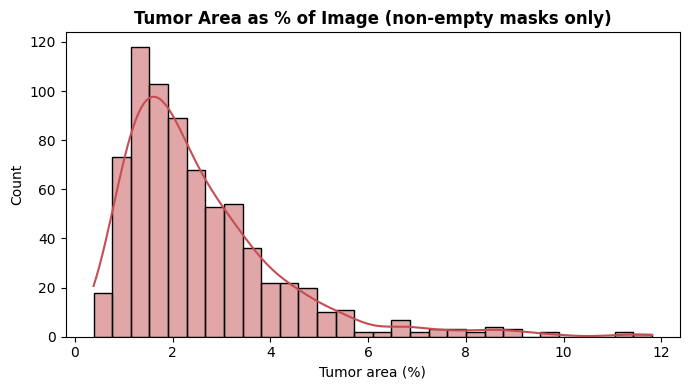

Images with a non-empty tumor mask (train): 48.6%


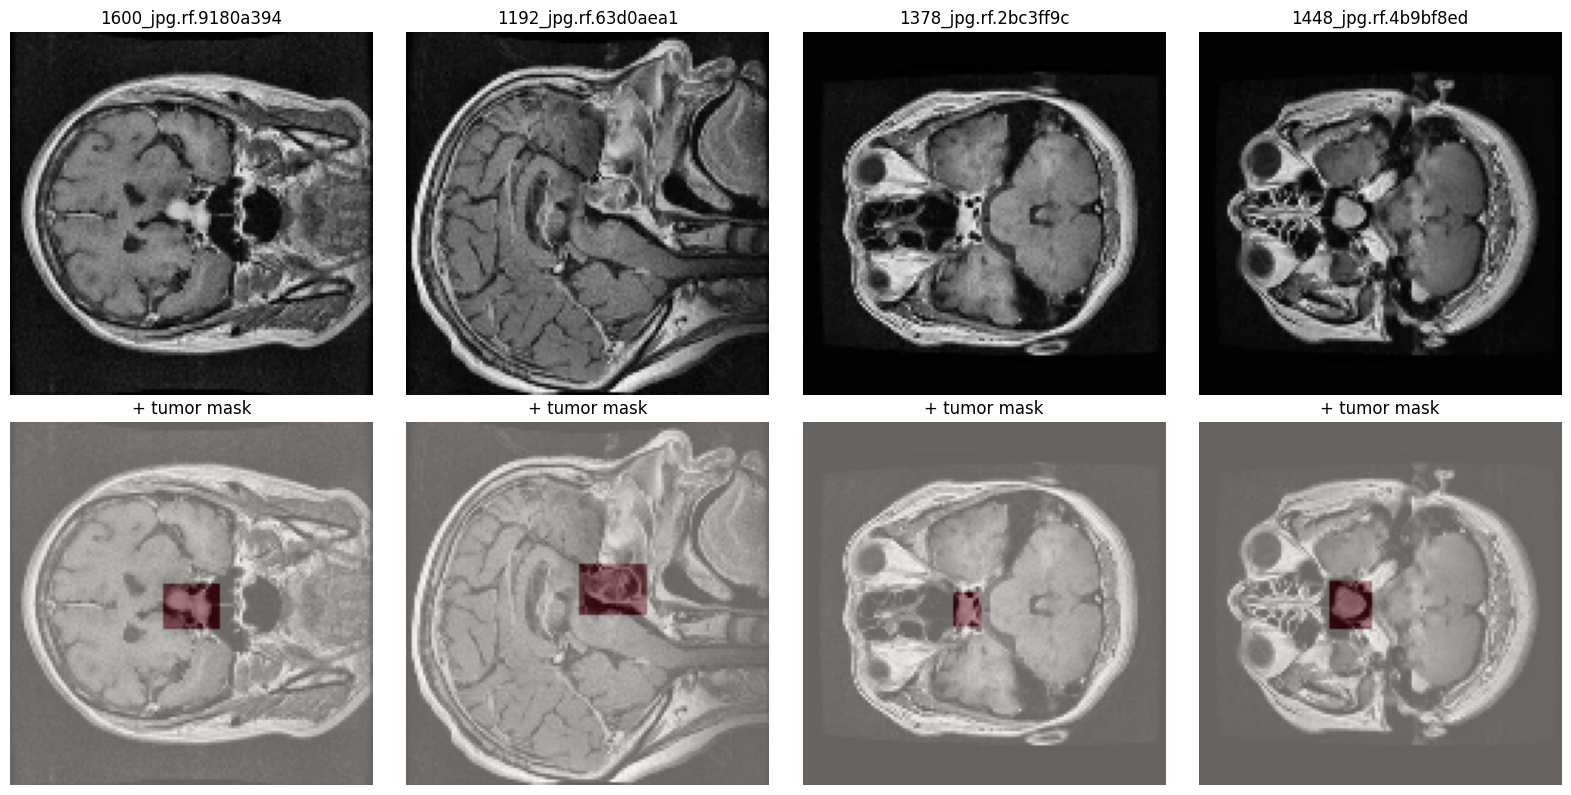

In [80]:
# --- Tumor pixel-area distribution (as % of image) ---
tumor_area_pct = mask_train.reshape(len(mask_train), -1).mean(axis=1) * 100

plt.figure(figsize=(7, 4))
sns.histplot(tumor_area_pct[tumor_area_pct > 0], bins=30, kde=True, color='#C44E52')
plt.title('Tumor Area as % of Image (non-empty masks only)', fontweight='bold')
plt.xlabel('Tumor area (%)'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

pct_with_tumor = (tumor_area_pct > 0).mean() * 100
print(f"Images with a non-empty tumor mask (train): {pct_with_tumor:.1f}%")

# --- A few image / mask overlay examples ---
tumor_idx = np.where(tumor_area_pct > 0)[0]
sample_idx = np.random.RandomState(RANDOM_STATE).choice(tumor_idx, size=min(4, len(tumor_idx)), replace=False)

fig, axes = plt.subplots(2, len(sample_idx), figsize=(4 * len(sample_idx), 8))
for j, idx in enumerate(sample_idx):
    axes[0, j].imshow(X_train_raw[idx]); axes[0, j].set_title(f_train[idx][:20]); axes[0, j].axis('off')
    axes[1, j].imshow(X_train_raw[idx])
    axes[1, j].imshow(mask_train[idx, :, :, 0], alpha=0.4, cmap='Reds')
    axes[1, j].set_title('+ tumor mask'); axes[1, j].axis('off')
plt.tight_layout(); plt.show()

## 19. Centralized Models — CNN U-Net & Transformer U-Net

Both share the same encoder/decoder skeleton and loss/metrics so the
comparison isolates the effect of the bottleneck (plain conv stack vs. a
self-attention transformer block).

In [81]:
SEG_EPOCHS = 15

def dice_coef(y_true, y_pred, smooth=1.0):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)


def iou_coef(y_true, y_pred, smooth=1.0):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return tf.reduce_mean(bce) + dice_loss(y_true, y_pred)


def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return x


def build_unet(img_size=IMG_SIZE, lr=LEARNING_RATE, name='CNN_UNet'):
    '''Standard 4-level U-Net encoder/decoder with skip connections.'''
    inputs = layers.Input(shape=(img_size, img_size, 3))

    c1 = conv_block(inputs, 32);  p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, 64);      p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, 128);     p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, 256);     p4 = layers.MaxPooling2D()(c4)

    bn = conv_block(p4, 512)  # bottleneck

    u4 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(bn)
    u4 = layers.Concatenate()([u4, c4]); u4 = conv_block(u4, 256)

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(u4)
    u3 = layers.Concatenate()([u3, c3]); u3 = conv_block(u3, 128)

    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(u3)
    u2 = layers.Concatenate()([u2, c2]); u2 = conv_block(u2, 64)

    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(u2)
    u1 = layers.Concatenate()([u1, c1]); u1 = conv_block(u1, 32)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(u1)

    model = Model(inputs, outputs, name=name)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss=bce_dice_loss, metrics=[dice_coef, iou_coef])
    return model


def transformer_bottleneck(x, num_heads=4, key_dim=32, ff_dim=512):
    '''Lightweight ViT-style block applied at the U-Net bottleneck: flatten
    the (H, W, C) feature map to a sequence of patch tokens, run multi-head
    self-attention + an MLP with residual connections, reshape back.'''
    b, h, w, c = x.shape
    seq = layers.Reshape((h * w, c))(x)

    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(seq, seq)
    seq = layers.Add()([seq, attn_out])
    seq = layers.LayerNormalization()(seq)

    mlp = layers.Dense(ff_dim, activation='relu')(seq)
    mlp = layers.Dense(c)(mlp)
    seq = layers.Add()([seq, mlp])
    seq = layers.LayerNormalization()(seq)

    return layers.Reshape((h, w, c))(seq)


def build_transformer_unet(img_size=IMG_SIZE, lr=LEARNING_RATE, name='Transformer_UNet'):
    '''Same U-Net encoder/decoder as build_unet(), but the bottleneck is a
    transformer self-attention block instead of a plain conv block — lets the
    bottleneck reason about long-range spatial relationships across the whole
    feature map before decoding back up.'''
    inputs = layers.Input(shape=(img_size, img_size, 3))

    c1 = conv_block(inputs, 32);  p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, 64);      p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, 128);     p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, 256);     p4 = layers.MaxPooling2D()(c4)

    bn = layers.Conv2D(512, 3, padding='same', activation='relu')(p4)
    bn = layers.BatchNormalization()(bn)
    bn = transformer_bottleneck(bn, num_heads=4, key_dim=32, ff_dim=512)

    u4 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(bn)
    u4 = layers.Concatenate()([u4, c4]); u4 = conv_block(u4, 256)

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(u4)
    u3 = layers.Concatenate()([u3, c3]); u3 = conv_block(u3, 128)

    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(u3)
    u2 = layers.Concatenate()([u2, c2]); u2 = conv_block(u2, 64)

    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(u2)
    u1 = layers.Concatenate()([u1, c1]); u1 = conv_block(u1, 32)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(u1)

    model = Model(inputs, outputs, name=name)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss=bce_dice_loss, metrics=[dice_coef, iou_coef])
    return model


print("✅ build_unet() and build_transformer_unet() defined")

✅ build_unet() and build_transformer_unet() defined


Training Centralized CNN U-Net...
Epoch 1/15


2026-08-08 14:27:18.584116: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 14:27:18.868796: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 14:27:19.649724: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 14:27:19.949389: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 14:27:20.755780: E external/local_xla/xla/stream_

 1/94 ━━━━━━━━━━━━━━━━━━━━ 48:23 31s/step - dice_coef: 0.0249 - iou_coef: 0.0126 - loss: 1.8266

I0000 00:00:1786199252.767603     177 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - dice_coef: 0.0303 - iou_coef: 0.0154 - loss: 1.7156

2026-08-08 14:27:47.531409: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 14:27:47.817313: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 14:27:48.563442: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 14:27:48.861279: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 14:27:49.666856: E external/local_xla/xla/stream_

94/94 ━━━━━━━━━━━━━━━━━━━━ 68s 397ms/step - dice_coef: 0.0349 - iou_coef: 0.0178 - loss: 1.6651 - val_dice_coef: 0.0264 - val_iou_coef: 0.0135 - val_loss: 1.5619 - learning_rate: 1.0000e-04
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - dice_coef: 0.0495 - iou_coef: 0.0254 - loss: 1.5433 - val_dice_coef: 0.0252 - val_iou_coef: 0.0129 - val_loss: 1.3740 - learning_rate: 1.0000e-04
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - dice_coef: 0.0558 - iou_coef: 0.0288 - loss: 1.4721 - val_dice_coef: 0.0248 - val_iou_coef: 0.0127 - val_loss: 1.3597 - learning_rate: 1.0000e-04
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - dice_coef: 0.0612 - iou_coef: 0.0317 - loss: 1.4175 - val_dice_coef: 0.0350 - val_iou_coef: 0.0180 - val_loss: 1.3126 - learning_rate: 1.0000e-04
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - dice_coef: 0.0663 - iou_coef: 0.0344 - loss: 1.3696 - val_dice_coef: 0.0688 - val_iou_coef: 0.0365 - val_loss: 1.2689 - learning_rate: 1.0000e-04
Epoch 6/15
94

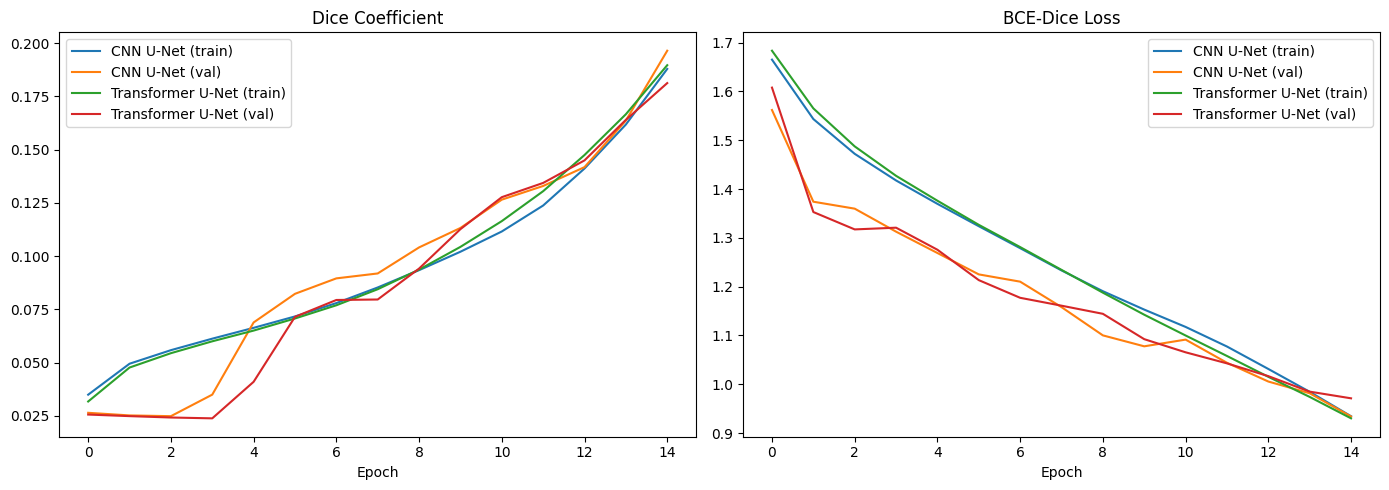

In [82]:
seg_callbacks = lambda: [
    tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', mode='max', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
]

print("Training Centralized CNN U-Net...")
cnn_unet = build_unet(name='Centralized_CNN_UNet')
cnn_unet_history = cnn_unet.fit(
    X_train_raw, mask_train,
    validation_data=(X_val_raw, mask_val),
    epochs=SEG_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=seg_callbacks(), verbose=1
)
cnn_unet.save_weights(os.path.join(MODEL_DIR, 'centralized_cnn_unet.weights.h5'))

print("\nTraining Centralized Transformer U-Net...")
trans_unet = build_transformer_unet(name='Centralized_Transformer_UNet')
trans_unet_history = trans_unet.fit(
    X_train_raw, mask_train,
    validation_data=(X_val_raw, mask_val),
    epochs=SEG_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=seg_callbacks(), verbose=1
)
trans_unet.save_weights(os.path.join(MODEL_DIR, 'centralized_transformer_unet.weights.h5'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(cnn_unet_history.history['dice_coef'], label='CNN U-Net (train)')
axes[0].plot(cnn_unet_history.history['val_dice_coef'], label='CNN U-Net (val)')
axes[0].plot(trans_unet_history.history['dice_coef'], label='Transformer U-Net (train)')
axes[0].plot(trans_unet_history.history['val_dice_coef'], label='Transformer U-Net (val)')
axes[0].set_title('Dice Coefficient'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(cnn_unet_history.history['loss'], label='CNN U-Net (train)')
axes[1].plot(cnn_unet_history.history['val_loss'], label='CNN U-Net (val)')
axes[1].plot(trans_unet_history.history['loss'], label='Transformer U-Net (train)')
axes[1].plot(trans_unet_history.history['val_loss'], label='Transformer U-Net (val)')
axes[1].set_title('BCE-Dice Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

## 20. Centralized Segmentation — Performance Baseline

In [83]:
def evaluate_segmentation(model, X, y_true_masks, threshold=0.5, name='model'):
    '''Pixel-level Dice / IoU / Precision / Recall / F1 on a held-out set.'''
    y_pred_proba = model.predict(X, verbose=0)
    y_pred = (y_pred_proba > threshold).astype(np.uint8)

    yt = y_true_masks.flatten().astype(np.uint8)
    yp = y_pred.flatten()

    dice = float(dice_coef(y_true_masks, y_pred_proba).numpy())
    iou  = float(iou_coef(y_true_masks, y_pred_proba).numpy())
    prec = precision_score(yt, yp, zero_division=0)
    rec  = recall_score(yt, yp, zero_division=0)
    f1   = f1_score(yt, yp, zero_division=0)

    print(f"{name:32s} | Dice={dice:.4f}  IoU={iou:.4f}  "
          f"Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")
    return {'model': name, 'dice': dice, 'iou': iou, 'precision': prec, 'recall': rec, 'f1': f1}


seg_results = []
seg_results.append(evaluate_segmentation(cnn_unet,   X_test_raw, mask_test, name='Centralized CNN U-Net'))
seg_results.append(evaluate_segmentation(trans_unet, X_test_raw, mask_test, name='Centralized Transformer U-Net'))

seg_results_df = pd.DataFrame(seg_results)
seg_results_df

Centralized CNN U-Net            | Dice=0.1811  IoU=0.0996  Precision=0.7418  Recall=0.8485  F1=0.7916
Centralized Transformer U-Net    | Dice=0.1695  IoU=0.0926  Precision=0.7025  Recall=0.8577  F1=0.7723


,model,dice,iou,precision,recall,f1
0,Centralized CNN U-Net,0.181114,0.099576,0.741848,0.848531,0.791611
1,Centralized Transformer U-Net,0.169495,0.092596,0.702463,0.857676,0.772349


## 21. Federated Client Setup (Segmentation)

Reuses `create_iid_clients` / `create_noniid_clients` from Part 1 (step 12),
now applied to image + mask pairs instead of image + label pairs.

In [84]:
def create_iid_clients_seg(X, M, num_clients=NUM_CLIENTS, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(X))
    X, M = X[idx], M[idx]
    size = len(X) // num_clients
    clients = []
    for i in range(num_clients):
        start = i * size
        end   = start + size if i < num_clients - 1 else len(X)
        clients.append((X[start:end], M[start:end]))
    return clients


def create_noniid_clients_seg(X, M, num_clients=NUM_CLIENTS, alpha=DIRICHLET_ALPHA, seed=RANDOM_STATE):
    '''Non-IID split driven by whether each image has a non-empty tumor
    mask (the segmentation analogue of the label-skew used for the
    classification clients in Part 1).'''
    rng = np.random.RandomState(seed)
    has_tumor = (M.reshape(len(M), -1).sum(axis=1) > 0).astype(int)
    classes = np.unique(has_tumor)
    client_indices = [[] for _ in range(num_clients)]

    for c in classes:
        c_idx = np.where(has_tumor == c)[0]
        rng.shuffle(c_idx)
        proportions = rng.dirichlet(alpha=[alpha] * num_clients)
        split_points = (np.cumsum(proportions) * len(c_idx)).astype(int)[:-1]
        for client_id, idx_chunk in enumerate(np.split(c_idx, split_points)):
            client_indices[client_id].extend(idx_chunk.tolist())

    clients = []
    for idx_list in client_indices:
        idx_arr = np.array(idx_list)
        rng.shuffle(idx_arr)
        clients.append((X[idx_arr], M[idx_arr]))
    return clients


if CLIENT_PARTITION == 'non_iid':
    fl_clients_seg = create_noniid_clients_seg(X_train_raw, mask_train, NUM_CLIENTS, DIRICHLET_ALPHA)
else:
    fl_clients_seg = create_iid_clients_seg(X_train_raw, mask_train, NUM_CLIENTS)

print(f"Segmentation partitioning strategy: {CLIENT_PARTITION}")
for i, (cx, cm) in enumerate(fl_clients_seg):
    tumor_frac = (cm.reshape(len(cm), -1).sum(axis=1) > 0).mean() * 100
    print(f"  Client {i+1}: {cx.shape[0]} samples | {tumor_frac:.1f}% have a tumor mask")

Segmentation partitioning strategy: iid
  Client 1: 300 samples | 50.0% have a tumor mask
  Client 2: 300 samples | 48.3% have a tumor mask
  Client 3: 300 samples | 47.3% have a tumor mask
  Client 4: 300 samples | 49.7% have a tumor mask
  Client 5: 302 samples | 47.7% have a tumor mask


## 22. Local Model Training — Gradient Computation (Segmentation)

Same gradient-accumulation-then-FedAvg design as Part 1 (steps 13–14), now
using the BCE-Dice segmentation loss. One shared function trains whichever
model builder (`build_unet` or `build_transformer_unet`) is passed in, so
both federated U-Net variants reuse the exact same FL loop.

In [85]:
def compute_local_gradients_seg(model_builder, global_weights, client_X, client_M, epochs=EPOCHS_PER_CLIENT):
    local_model = model_builder(name='client_tmp_seg')
    local_model.set_weights(global_weights)

    local_optimizer = tf.keras.optimizers.Adam(LEARNING_RATE)

    trainable_vars = local_model.trainable_variables
    grad_sum  = [tf.zeros_like(v) for v in trainable_vars]
    n_batches = 0

    ds = tf.data.Dataset.from_tensor_slices((client_X, client_M)) \
                         .shuffle(len(client_X), seed=RANDOM_STATE) \
                         .batch(BATCH_SIZE)

    for epoch in range(epochs):
        for xb, mb in ds:
            with tf.GradientTape() as tape:
                preds = local_model(xb, training=True)
                loss  = bce_dice_loss(mb, preds)
            grads = tape.gradient(loss, trainable_vars)

            grad_sum  = [gs + g for gs, g in zip(grad_sum, grads)]
            n_batches += 1
            local_optimizer.apply_gradients(zip(grads, trainable_vars))

    avg_grads = [gs / max(n_batches, 1) for gs in grad_sum]
    bn_state = [v.numpy() for v in local_model.non_trainable_weights]
    return avg_grads, bn_state, len(client_X)


def run_federated_segmentation(model_builder, model_label, warm_start_path=None):
    '''Full FedAvg loop for a segmentation model: NUM_ROUNDS rounds, each
    client trains locally then contributes size-weighted gradients + BN
    stats (aggregate_gradients / aggregate_bn_state reused from Part 1).'''
    print("=" * 70)
    print(f" FEDERATED LEARNING — {model_label} (Gradient Aggregation)")
    print("=" * 70)

    global_model = model_builder(name=f'FL_Global_{model_label}'.replace(' ', '_'))
    if warm_start_path and os.path.exists(warm_start_path):
        global_model.load_weights(warm_start_path)

    server_optimizer = tf.keras.optimizers.Adam(LEARNING_RATE)
    trainable_vars   = global_model.trainable_variables
    n_params_per_msg = sum(int(np.prod(v.shape)) for v in trainable_vars)

    val_dice_per_round, val_iou_per_round, round_times = [], [], []
    client_final_dice = None  # populated on the last round for client-wise analysis

    for rnd in range(NUM_ROUNDS):
        t0 = time.time()
        print(f"\n{'─'*60}\n {model_label} — Round {rnd+1}/{NUM_ROUNDS}\n{'─'*60}")

        global_weights = global_model.get_weights()
        client_grads_list, client_bn_list, client_sizes, client_dice_this_round = [], [], [], []

        for i, (cx, cm) in enumerate(fl_clients_seg):
            grads, bn_state, n = compute_local_gradients_seg(model_builder, global_weights, cx, cm)
            client_grads_list.append(grads)
            client_bn_list.append(bn_state)
            client_sizes.append(n)

            # quick local-model dice on this client's own data, for client-wise analysis
            tmp = model_builder(name='client_eval_tmp')
            tmp.set_weights(global_weights)
            local_preds = tmp.predict(cx, verbose=0)
            client_dice_this_round.append(float(dice_coef(cm, local_preds).numpy()))
            print(f"   Client {i+1}/{NUM_CLIENTS} — local gradients computed "
                  f"({n} samples, local Dice={client_dice_this_round[-1]:.4f})")

        agg_grads = aggregate_gradients(client_grads_list, client_sizes)
        server_optimizer.apply_gradients(zip(agg_grads, trainable_vars))

        agg_bn = aggregate_bn_state(client_bn_list, client_sizes)
        for v, new_val in zip(global_model.non_trainable_weights, agg_bn):
            v.assign(new_val)

        val_preds = global_model.predict(X_val_raw, verbose=0)
        val_dice = float(dice_coef(mask_val, val_preds).numpy())
        val_iou  = float(iou_coef(mask_val, val_preds).numpy())
        val_dice_per_round.append(val_dice)
        val_iou_per_round.append(val_iou)
        round_times.append(time.time() - t0)
        client_final_dice = client_dice_this_round

        print(f"   ✅ Round {rnd+1} — Global Val Dice={val_dice:.4f} IoU={val_iou:.4f} "
              f"(round wall-time: {round_times[-1]:.1f}s)")

    print(f"\n✅ Federated {model_label} training complete.")
    return {
        'model': global_model,
        'label': model_label,
        'val_dice_per_round': val_dice_per_round,
        'val_iou_per_round': val_iou_per_round,
        'round_times': round_times,
        'client_final_dice': client_final_dice,
        'n_params_per_msg': n_params_per_msg,
    }


print("✅ compute_local_gradients_seg() and run_federated_segmentation() defined")

✅ compute_local_gradients_seg() and run_federated_segmentation() defined


## 23. Federated CNN U-Net & Federated Transformer U-Net

In [86]:
fl_cnn_unet_result = run_federated_segmentation(
    build_unet, 'CNN U-Net',
    warm_start_path=os.path.join(MODEL_DIR, 'centralized_cnn_unet.weights.h5')
)

fl_trans_unet_result = run_federated_segmentation(
    build_transformer_unet, 'Transformer U-Net',
    warm_start_path=os.path.join(MODEL_DIR, 'centralized_transformer_unet.weights.h5')
)

 FEDERATED LEARNING — CNN U-Net (Gradient Aggregation)

────────────────────────────────────────────────────────────
 CNN U-Net — Round 1/3
────────────────────────────────────────────────────────────
   Client 1/5 — local gradients computed (300 samples, local Dice=0.2406)
   Client 2/5 — local gradients computed (300 samples, local Dice=0.2338)
   Client 3/5 — local gradients computed (300 samples, local Dice=0.2274)
   Client 4/5 — local gradients computed (300 samples, local Dice=0.2485)
   Client 5/5 — local gradients computed (302 samples, local Dice=0.2491)
   ✅ Round 1 — Global Val Dice=0.2126 IoU=0.1190 (round wall-time: 152.2s)

────────────────────────────────────────────────────────────
 CNN U-Net — Round 2/3
────────────────────────────────────────────────────────────
   Client 1/5 — local gradients computed (300 samples, local Dice=0.2260)
   Client 2/5 — local gradients computed (300 samples, local Dice=0.2195)
   Client 3/5 — local gradients computed (300 samples, local

## 24. Centralized vs. Federated — Dice / IoU / Precision / Recall / F1

Federated CNN U-Net              | Dice=0.1570  IoU=0.0852  Precision=0.7593  Recall=0.8327  F1=0.7943
Federated Transformer U-Net      | Dice=0.1429  IoU=0.0770  Precision=0.7664  Recall=0.7581  F1=0.7622


,model,dice,iou,precision,recall,f1
0,Centralized CNN U-Net,0.181114,0.099576,0.741848,0.848531,0.791611
1,Centralized Transformer U-Net,0.169495,0.092596,0.702463,0.857676,0.772349
2,Federated CNN U-Net,0.157023,0.085202,0.759253,0.832738,0.794299
3,Federated Transformer U-Net,0.142907,0.076953,0.766375,0.758061,0.762195


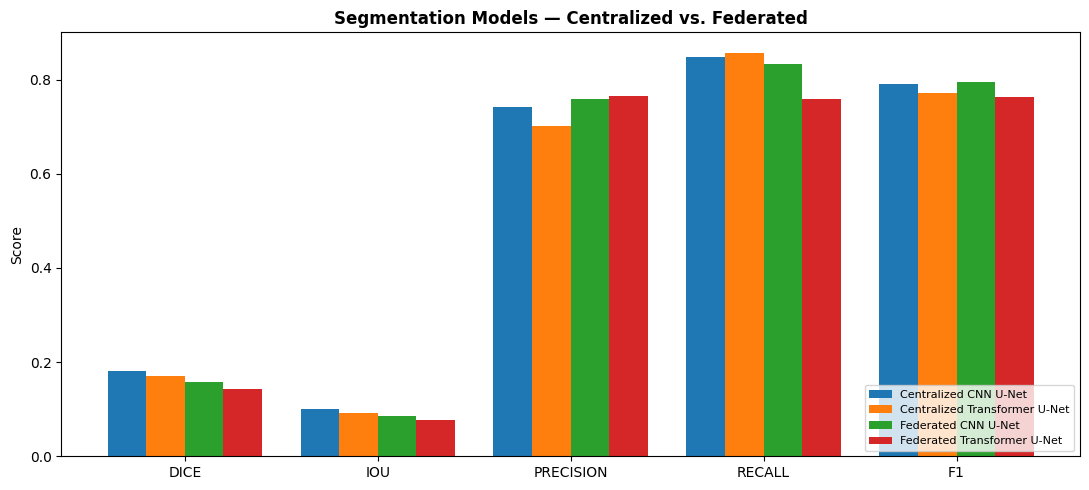

In [87]:
seg_results.append(evaluate_segmentation(fl_cnn_unet_result['model'],   X_test_raw, mask_test, name='Federated CNN U-Net'))
seg_results.append(evaluate_segmentation(fl_trans_unet_result['model'], X_test_raw, mask_test, name='Federated Transformer U-Net'))

seg_results_df = pd.DataFrame(seg_results)
display(seg_results_df)

metrics_to_plot = ['dice', 'iou', 'precision', 'recall', 'f1']
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(metrics_to_plot))
width = 0.2
for i, row in seg_results_df.iterrows():
    ax.bar(x + i * width, [row[m] for m in metrics_to_plot], width, label=row['model'])
ax.set_xticks(x + width * (len(seg_results_df) - 1) / 2)
ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylabel('Score'); ax.set_title('Segmentation Models — Centralized vs. Federated', fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

## 25. Client-wise Analysis

,Client,"CNN U-Net (local Dice, final round)","Transformer U-Net (local Dice, final round)"
0,Client 1,0.217529,0.210140
1,Client 2,0.211078,0.205500
2,Client 3,0.205217,0.197279
3,Client 4,0.224794,0.218534
4,Client 5,0.225432,0.219110


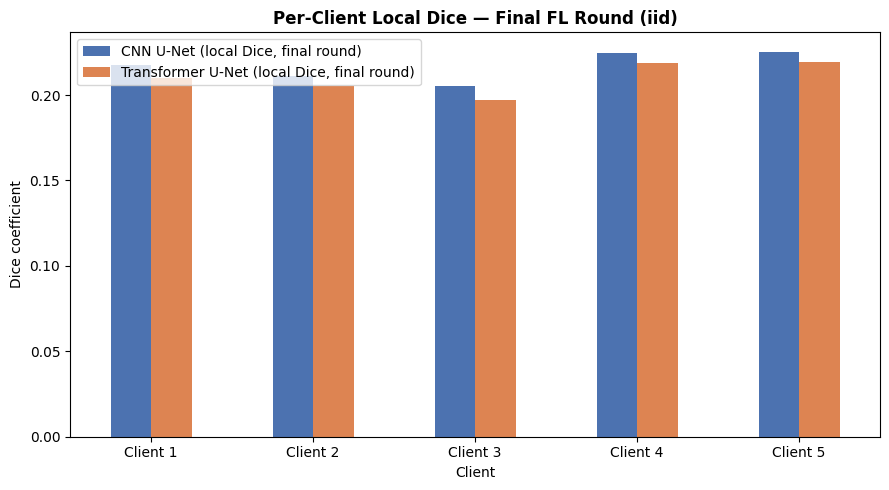

In [88]:
client_wise_df = pd.DataFrame({
    'Client': [f'Client {i+1}' for i in range(NUM_CLIENTS)],
    'CNN U-Net (local Dice, final round)': fl_cnn_unet_result['client_final_dice'],
    'Transformer U-Net (local Dice, final round)': fl_trans_unet_result['client_final_dice'],
})
display(client_wise_df)

client_wise_df.set_index('Client').plot(kind='bar', figsize=(9, 5), color=['#4C72B0', '#DD8452'])
plt.title(f'Per-Client Local Dice — Final FL Round ({CLIENT_PARTITION})', fontweight='bold')
plt.ylabel('Dice coefficient'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 26. FL Convergence Analysis

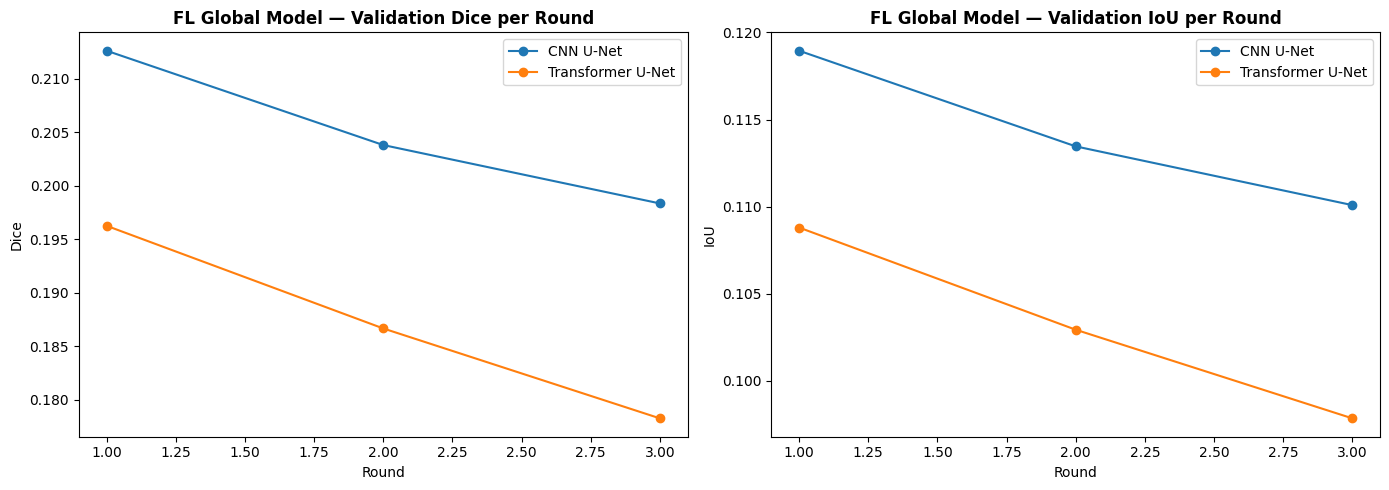

Round wall-times (s):
  CNN U-Net        : ['152.2', '137.1', '136.4']
  Transformer U-Net: ['161.2', '157.2', '156.5']


In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rounds_x = range(1, NUM_ROUNDS + 1)

axes[0].plot(rounds_x, fl_cnn_unet_result['val_dice_per_round'], marker='o', label='CNN U-Net')
axes[0].plot(rounds_x, fl_trans_unet_result['val_dice_per_round'], marker='o', label='Transformer U-Net')
axes[0].set_title('FL Global Model — Validation Dice per Round', fontweight='bold')
axes[0].set_xlabel('Round'); axes[0].set_ylabel('Dice'); axes[0].legend()

axes[1].plot(rounds_x, fl_cnn_unet_result['val_iou_per_round'], marker='o', label='CNN U-Net')
axes[1].plot(rounds_x, fl_trans_unet_result['val_iou_per_round'], marker='o', label='Transformer U-Net')
axes[1].set_title('FL Global Model — Validation IoU per Round', fontweight='bold')
axes[1].set_xlabel('Round'); axes[1].set_ylabel('IoU'); axes[1].legend()

plt.tight_layout(); plt.show()

print("Round wall-times (s):")
print("  CNN U-Net        :", [f"{t:.1f}" for t in fl_cnn_unet_result['round_times']])
print("  Transformer U-Net:", [f"{t:.1f}" for t in fl_trans_unet_result['round_times']])

## 27. Communication Analysis

,model,params_per_message,MB_per_round,MB_total_FL_training,MB_send_raw_data_once
0,CNN U-Net,7765985,296.248817,888.746452,375.5
1,Transformer U-Net,6195553,236.341591,709.024773,375.5


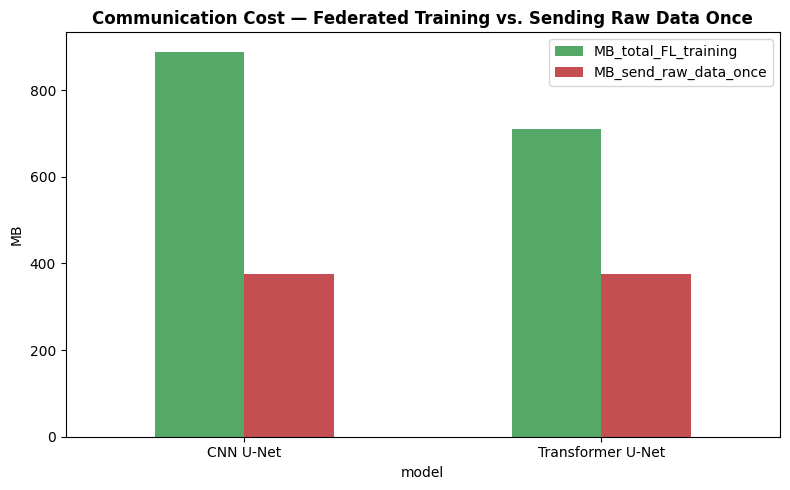

In [90]:
def communication_report(result, bytes_per_param=4):
    n_params = result['n_params_per_msg']
    bytes_per_round = n_params * bytes_per_param * NUM_CLIENTS * 2  # up + down per client
    total_bytes = bytes_per_round * NUM_ROUNDS
    return {
        'model': result['label'],
        'params_per_message': n_params,
        'MB_per_round': bytes_per_round / (1024 ** 2),
        'MB_total_FL_training': total_bytes / (1024 ** 2),
    }


comm_df = pd.DataFrame([
    communication_report(fl_cnn_unet_result),
    communication_report(fl_trans_unet_result),
])

# Rough comparison point: cost of instead centralizing all raw client image+mask data once
raw_bytes = (X_train_raw.nbytes + mask_train.nbytes)
comm_df['MB_send_raw_data_once'] = raw_bytes / (1024 ** 2)

display(comm_df)

comm_df.set_index('model')[['MB_total_FL_training', 'MB_send_raw_data_once']].plot(
    kind='bar', figsize=(8, 5), color=['#55A868', '#C44E52']
)
plt.title('Communication Cost — Federated Training vs. Sending Raw Data Once', fontweight='bold')
plt.ylabel('MB'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()



- **Mask source.** Masks are rasterized on the fly from each split's
  `_annotations.coco.json` polygon annotations (Roboflow export) — there are
  no separate per-pixel mask image files in this dataset variant.
- **Loss.** Combined BCE + Dice loss (`bce_dice_loss`) — standard choice for
  segmentation with class-imbalanced (mostly-background) masks.
- **Bottleneck comparison.** `build_unet` and `build_transformer_unet` share
  an identical encoder/decoder; only the bottleneck differs (plain conv block
  vs. multi-head self-attention block), isolating the transformer's effect.
- **Federated segmentation.** Reuses the exact gradient-accumulation +
  size-weighted FedAvg design from Part 1 (steps 13–14), generalized to any
  model builder via `run_federated_segmentation(model_builder, label)`, so
  both federated U-Net variants share one FL loop implementation.
- **Client-wise / convergence / communication analysis** mirror the
  classification-side analysis in Part 1, now computed per segmentation
  model and per FL round.